# Simulación

1. **Contexto y Sistema Real** El sistema bajo estudio consiste en la infraestructura de servidores on-premise de una compañía tecnológica en fase de expansión. El punto crítico de acceso es el puerto 51413, el cual centraliza el tráfico de servicios y aplicaciones críticas. Actualmente, el sistema opera bajo una arquitectura de balanceo de carga (Load Balancing) que distribuye los flujos entrantes entre múltiples unidades de procesamiento.
2. **Definición del Problema** Ante el crecimiento de la demanda, la empresa enfrenta la necesidad de validar su capacidad de respuesta y determinar si se requiere inversión en hardware adicional o una reconfiguración de la lógica de despacho. El desafío principal es garantizar la Calidad de Servicio (QoS), evitando la saturación de los servidores y minimizando los tiempos de espera. Los paquetes esperan un TTL antes de descartarse. Esto se calcula cuando se les asigna un servidor. Si el servidor atiende hasta 100 flujos actualmente, el paquete calcula que va a llegar a destino a tiempo. Caso contrario, el 30% rechaza la conexión hasta 300 flujos, el 80% rechaza la conexión hasta 500 flujos y si hay más flujos en el servidor, la conexión siempre se va a rechazar. Lo mismo ocurre si una petición espera más de un tiempo preestablecido de Timeout.
3. **Objetivo de la Simulación** Evaluar el comportamiento del sistema mediante la metodología de Evento a Evento (EaE) para determinar la configuración óptima de servidores (Variables de Control $N$ y $M$). Se busca maximizar el throughput y minimizar el tiempo de permanencia en el sistema, analizando tres escenarios: actual, mejor y peor caso.


## Generación de variables + carga de dataset

*Para poder ejecutar correctamente esta sección, primero hay que correr el notebook de **'preparacion_dataset.ipynb'***

In [52]:
import pandas as pd
tabla_de_eventos_futuros = pd.read_csv("./dataset/datasetFinalSimulacion.csv")

tabla_de_eventos_futuros

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol_label,Timestamp,Flow Duration,IntervaloEntreFlujos,IntervaloEntreFlujos_seg
0,131.202.240.87-199.195.249.48-61009-51413-17,131.202.240.87,61009,199.195.249.48,51413,UDP,2015-05-01 11:37:47,64007541,NaN,NaN
1,131.202.240.87-107.191.41.12-61009-51413-17,131.202.240.87,61009,107.191.41.12,51413,UDP,2015-05-01 11:38:51,64049895,0 days 00:01:04,64.0
2,131.202.240.87-74.207.253.79-61009-51413-17,131.202.240.87,61009,74.207.253.79,51413,UDP,2015-05-01 11:38:51,64106424,0 days 00:00:00,0.0
3,131.202.240.87-65.98.72.100-61009-51413-17,131.202.240.87,61009,65.98.72.100,51413,UDP,2015-05-01 11:39:00,54869,0 days 00:00:09,9.0
4,131.202.240.87-79.132.74.152-61009-51413-17,131.202.240.87,61009,79.132.74.152,51413,UDP,2015-05-01 11:39:15,189748,0 days 00:00:15,15.0
...,...,...,...,...,...,...,...,...,...,...
6303,10.152.152.11-103.198.172.77-45213-51413-6,10.152.152.11,45213,103.198.172.77,51413,TCP,2016-02-24 11:33:58,409475,0 days 00:00:00,0.0
6304,10.152.152.11-87.94.140.155-33760-51413-6,10.152.152.11,33760,87.94.140.155,51413,TCP,2016-02-24 11:34:08,4705193,0 days 00:00:10,10.0
6305,10.152.152.11-87.94.140.155-33760-51413-6,10.152.152.11,33760,87.94.140.155,51413,TCP,2016-02-24 11:34:08,4705193,0 days 00:00:00,0.0
6306,10.152.152.11-217.250.238.213-55312-51413-6,10.152.152.11,55312,217.250.238.213,51413,TCP,2016-02-24 11:34:14,1109,0 days 00:00:06,6.0


## Rutina de ingreso a Eventos

### Variables Exógenas:
#### Datos:
* **IA:** Intervalo entre arribos de flujos (según f.d.p. Kappa3 del TP4).
* **TA_UDP:** Tiempo de atención/procesamiento de flujos UDP (según f.d.p. Lomax del TP4).
* **TA_TCP:** Tiempo de atención/procesamiento de flujos TCP (según f.d.p. Lomax del TP4).

#### Variable de Control:
* **N:** Cantidad de Servidores dedicados exclusivamente a UDP (Clase A).
* **M:** Cantidad de Servidores generales para TCP/UDP (Clase B).
* **TO:** Timeout de una conexión.

### Variables Endógenas:
#### Variable de Estado:
* **CU:** Cantidad de flujos UDP en cola. Donde N es límite hasta donde llega i
* **CT:** Cantidad de flujos TCP en cola. Donde M es límite hasta donde llega j
* **CSA:** Cantidad de Servidores Clase A ocupados.
* **CSB:** Cantidad de Servidores Clase B ocupados.

#### Variable de Resultado:
* **PEC_U:** Promedio de espera en cola de los flujos UDP.
* **PEC_T:** Promedio de espera en cola de los flujos TCP.
* **PTO_A (I):** Porcentaje de tiempo ocioso de cada servidor Clase A.
* **PTO_B (I):** Porcentaje de tiempo ocioso de cada servidor Clase B.
* **NTU:** Cantidad total de flujos UDP atendidos.
* **NTT:** Cantidad total de flujos TCP atendidos.
* **PAT:** Porcentaje de Flujos totales arrepentidos TCP respecto a los que no se arrepienten.

# Simulación

1. **Contexto y Sistema Real** El sistema bajo estudio consiste en la infraestructura de servidores on-premise de una compañía tecnológica en fase de expansión. El punto crítico de acceso es el puerto 51413, el cual centraliza el tráfico de servicios y aplicaciones críticas. Actualmente, el sistema opera bajo una arquitectura de balanceo de carga (Load Balancing) que distribuye los flujos entrantes entre múltiples unidades de procesamiento.
2. **Definición del Problema** Ante el crecimiento de la demanda, la empresa enfrenta la necesidad de validar su capacidad de respuesta y determinar si se requiere inversión en hardware adicional o una reconfiguración de la lógica de despacho. El desafío principal es garantizar la Calidad de Servicio (QoS), evitando la saturación de los servidores y minimizando los tiempos de espera. Los paquetes esperan un TTL antes de descartarse. Esto se calcula cuando se les asigna un servidor. Si el servidor atiende hasta 100 flujos actualmente, el paquete calcula que va a llegar a destino a tiempo. Caso contrario, el 30% rechaza la conexión hasta 300 flujos, el 80% rechaza la conexión hasta 500 flujos y si hay más flujos en el servidor, la conexión siempre se va a rechazar. Lo mismo ocurre si una petición espera más de un tiempo preestablecido de Timeout.
3. **Objetivo de la Simulación** Evaluar el comportamiento del sistema mediante la metodología de Evento a Evento (EaE) para determinar la configuración óptima de servidores (Variables de Control $N$ y $M$). Se busca maximizar el throughput y minimizar el tiempo de permanencia en el sistema, analizando tres escenarios: actual, mejor y peor caso.


## Generación de variables + carga de dataset

*Para poder ejecutar correctamente esta sección, primero hay que correr el notebook de **'preparacion_dataset.ipynb'***

In [53]:
import pandas as pd
import numpy as np
tabla_de_eventos_futuros = pd.read_csv("./dataset/datasetFinalSimulacion.csv")

tabla_de_eventos_futuros

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol_label,Timestamp,Flow Duration,IntervaloEntreFlujos,IntervaloEntreFlujos_seg
0,131.202.240.87-199.195.249.48-61009-51413-17,131.202.240.87,61009,199.195.249.48,51413,UDP,2015-05-01 11:37:47,64007541,NaN,NaN
1,131.202.240.87-107.191.41.12-61009-51413-17,131.202.240.87,61009,107.191.41.12,51413,UDP,2015-05-01 11:38:51,64049895,0 days 00:01:04,64.0
2,131.202.240.87-74.207.253.79-61009-51413-17,131.202.240.87,61009,74.207.253.79,51413,UDP,2015-05-01 11:38:51,64106424,0 days 00:00:00,0.0
3,131.202.240.87-65.98.72.100-61009-51413-17,131.202.240.87,61009,65.98.72.100,51413,UDP,2015-05-01 11:39:00,54869,0 days 00:00:09,9.0
4,131.202.240.87-79.132.74.152-61009-51413-17,131.202.240.87,61009,79.132.74.152,51413,UDP,2015-05-01 11:39:15,189748,0 days 00:00:15,15.0
...,...,...,...,...,...,...,...,...,...,...
6303,10.152.152.11-103.198.172.77-45213-51413-6,10.152.152.11,45213,103.198.172.77,51413,TCP,2016-02-24 11:33:58,409475,0 days 00:00:00,0.0
6304,10.152.152.11-87.94.140.155-33760-51413-6,10.152.152.11,33760,87.94.140.155,51413,TCP,2016-02-24 11:34:08,4705193,0 days 00:00:10,10.0
6305,10.152.152.11-87.94.140.155-33760-51413-6,10.152.152.11,33760,87.94.140.155,51413,TCP,2016-02-24 11:34:08,4705193,0 days 00:00:00,0.0
6306,10.152.152.11-217.250.238.213-55312-51413-6,10.152.152.11,55312,217.250.238.213,51413,TCP,2016-02-24 11:34:14,1109,0 days 00:00:06,6.0


## Rutina de ingreso a Eventos

### Variables Exógenas:
#### Datos:
* **IA:** Intervalo entre arribos de flujos (según f.d.p. Kappa3 del TP4).
* **TA_UDP:** Tiempo de atención/procesamiento de flujos UDP (según f.d.p. Lomax del TP4).
* **TA_TCP:** Tiempo de atención/procesamiento de flujos TCP (según f.d.p. Lomax del TP4).

#### Variable de Control:
* **N:** Cantidad de Servidores dedicados exclusivamente a UDP (Clase A).
* **M:** Cantidad de Servidores generales para TCP/UDP (Clase B).
* **TO:** Timeout de una conexión.

### Variables Endógenas:
#### Variable de Estado:
* **CU:** Cantidad de flujos UDP en cola. Donde N es límite hasta donde llega i
* **CT:** Cantidad de flujos TCP en cola. Donde M es límite hasta donde llega j
* **CSA:** Cantidad de Servidores Clase A ocupados.
* **CSB:** Cantidad de Servidores Clase B ocupados.

#### Variable de Resultado:
* **PEC_U:** Promedio de espera en cola de los flujos UDP.
* **PEC_T:** Promedio de espera en cola de los flujos TCP.
* **PTO_A (I):** Porcentaje de tiempo ocioso de cada servidor Clase A.
* **PTO_B (I):** Porcentaje de tiempo ocioso de cada servidor Clase B.
* **NTU:** Cantidad total de flujos UDP atendidos.
* **NTT:** Cantidad total de flujos TCP atendidos.
* **PAT:** Porcentaje de Flujos totales arrepentidos TCP respecto a los que no se arrepienten.

In [54]:
class Conexion:
    def __init__(self, ip, port, protocolo, ia, flow_duration, t_llegada):
        self.ip = ip
        self.port = port
        self.protocolo = protocolo
        self.ia = ia
        self.flow_duration = flow_duration
        self.t_llegada = t_llegada  # momento en que entro al sistema
        self.tps = 0.0

class Server:
    def __init__(self, tipo, server_id):
        self.type = tipo
        self.server_id = server_id
        self.total_leave_time = 0.0
        self.total_arrival_time = 0.0
        self.total_idle_time = 0.0
        self.total_service_time = 0.0  # FIX: acumula el tiempo de atencion real
        self.conexion_actual = None
        self.inicio_ocio = 0.0

    def sumar_tiempos_permanencia(self, t_salida, t_llegada, flow_duration):
        # FIX: recibe flow_duration para calcular tiempo de servicio real
        self.total_leave_time += t_salida
        self.total_arrival_time += t_llegada
        self.total_service_time += flow_duration

    def registrar_fin_ocio(self, t_actual):
        self.total_idle_time += (t_actual - self.inicio_ocio)

    def registrar_inicio_ocio(self, t_actual):
        self.inicio_ocio = t_actual


### Motor de Arribos y Lógica de Balking (Arrepentimiento)

Esta rutina corresponde al **Evento Futuro No Condicionado (EFNC) de Llegada**. Se encarga de inyectar las entidades al sistema y hacer avanzar el reloj de la simulación mediante la generación del próximo Intervalo de Arribo ($IA$) utilizando la FDP Kappa3 y asignando el Tiempo de Atención ($TA$) con la FDP Lomax obtenidas en el TP4.

**Lógica Estocástica de Arrepentimiento:**
Antes de ingresar, la entidad evalúa la carga actual del servidor consultando las Variables de Estado ($CU + CT + CSA + CSB$). Basado en los límites de tolerancia definidos en la arquitectura del modelo, se genera un número pseudoaleatorio $R \sim U(0,1)$ para determinar probabilísticamente si el flujo ingresa a las colas o es descartado por saturación:
* **$\le 100$ flujos:** Ingreso directo (0% arrepentimiento).
* **$101$ a $300$ flujos:** 30% de probabilidad de rechazo.
* **$301$ a $500$ flujos:** 80% de probabilidad de rechazo.
* **$> 500$ flujos:** Rechazo automático (100%).

Si la entidad no se arrepiente, se determina su protocolo y se la deriva a la rutina de procesamiento de eventos, respetando las Variables de Control ($N$ y $M$).

In [55]:
import random
from scipy import stats

params_kappa3 = {'a': np.float64(1.9334505996100626), 'loc': np.float64(-1.4041976152923097e-08), 'scale': np.float64(0.2975850690131321)*3}
params_lomax = {'c': np.float64(0.26427474769637876), 'loc': np.float64(0.13899999999345153), 'scale': np.float64(116.75079573241365)}
PROB_UDP = 0.85

contador_llegadas = 0

def generar_evento_llegada(estado):
    global contador_llegadas

    # 1. Generacion de variables aleatorias en milisegundos
    ia_seg = stats.kappa3.rvs(**params_kappa3)
    ia_ms = max(0, ia_seg * 1000)

    ta_ms = stats.lomax.rvs(**params_lomax)
    ta_ms = max(0, ta_ms)
    ta_ms = min(ta_ms, 10000)

    # 2. Determinacion del protocolo
    r_tipo = random.random()
    protocolo = 'UDP' if r_tipo <= PROB_UDP else 'TCP'

    # EFNC: el reloj avanza SIEMPRE antes de decidir si el flujo entra
    nuevo_tpll = estado.t + ia_ms

    # 3. Rutina de Arrepentimiento
    servidores_a_ocupados = sum(1 for s in estado.csa if s.conexion_actual is not None)
    servidores_b_ocupados = sum(1 for s in estado.csb if s.conexion_actual is not None)
    flujos_totales = len(estado.cu) + len(estado.ct) + servidores_a_ocupados + servidores_b_ocupados

    r_arr = random.random()
    arrepentido = False

    if flujos_totales <= 100:
        arrepentido = False
    elif 100 < flujos_totales <= 300:
        if r_arr <= 0.30:
            arrepentido = True
    elif 300 < flujos_totales <= 500:
        if r_arr <= 0.80:
            arrepentido = True
    else:
        arrepentido = True

    # FIX: incrementar total_llegadas antes de decidir si entra o no
    estado.total_llegadas += 1
    contador_llegadas += 1

    if arrepentido:
        estado.repentant_flows += 1
        estado.t = nuevo_tpll  # el reloj avanza igual
        # FIX: NO recalcular tpll aca, lo hace llegada_conexion
        return

    # 4. Inyeccion al sistema
    nueva_conexion = Conexion(
        ip="192.168.0.1", port=51413,
        protocolo=protocolo, ia=ia_ms,
        flow_duration=ta_ms, t_llegada=estado.t
    )
    nueva_conexion.tpll = nuevo_tpll
    estado.llegada_conexion(nueva_conexion)


## Rutina de procesamiento de evento

Para procesar los eventos, seguiremos la lógica propuesta en la presentación de la temática del tp:

| Evento     | EFNC    | EFC        | Condición                                                                                          |
|------------|---------|------------|----------------------------------------------------------------------------------------------------|
| Llegada    | Llegada | SalidaA (I) | (CU(i) = 1 y CSA <= N)                                                                            |
|            |         | SalidaB (I) | (CU(i) = 1 y CSA = N y CSB < M) OR<br>(CT(j) = 1 y CU(i) = 0 y CSB < M)                        |
| SalidaA (I)| -       | SalidaA (I) | CU(i) > 0                                                                                         |
| SalidaB (I)| -       | SalidaB (I) | Cu(i) >= 2 OR (CT(j) >= 1 y CU(i) <= 1)                                                          |


Según la prioridad, modificaremos las variables de estado

In [56]:
import sys

class Estado:
    def __init__(self, n, m, to):
        self.n = n
        self.m = m
        self.to = to
        self.t = 0.0
        self.tpll = 0.0
        self.ft = 0
        self.conexiones_procesadas = 0
        self.repentant_flows = 0
        self.total_llegadas = 0  # FIX: contador de todos los flujos que llegaron
        self.cu = []
        self.ct = []

        # Servidores como objetos Server
        self.csa = [Server('A', i) for i in range(n)]
        self.csb = [Server('B', i) for i in range(m)]
        self.servers = self.csa + self.csb

        # Tiempos de proxima salida por servidor
        self.tpsa = [sys.float_info.max] * n
        self.tpsb = [sys.float_info.max] * m

    def reportar_estado(self):
        print(f"T: {self.t:.2f}, TPLL: {self.tpll:.2f}")
        print(f"  CU: {len(self.cu)}, CT: {len(self.ct)}")
        print(f"  Conexiones procesadas: {self.conexiones_procesadas}")
        print(f"  Flujos arrepentidos: {self.repentant_flows}")
        print(f"  Total llegadas: {self.total_llegadas}")

    def servidor_disponible(self, lista_servidores):
        return any(s.conexion_actual is None for s in lista_servidores)

    def ocupar_servidor(self, lista_servidores, tps_lista, conexion):
        for i, servidor in enumerate(lista_servidores):
            if servidor.conexion_actual is None:
                servidor.registrar_fin_ocio(self.t)
                servidor.conexion_actual = conexion
                return i
        print("Error: todos los servidores llenos")
        return -1

    def liberar_conexion(self, lista_servidores, tps_lista, index):
        servidor = lista_servidores[index]
        conexion_saliente = servidor.conexion_actual
        if conexion_saliente is None:
            return None
        # FIX: pasar flow_duration para calcular tiempo de servicio real
        servidor.sumar_tiempos_permanencia(
            self.t,
            conexion_saliente.t_llegada,
            conexion_saliente.flow_duration
        )
        servidor.conexion_actual = None
        servidor.registrar_inicio_ocio(self.t)
        tps_lista[index] = sys.float_info.max
        return conexion_saliente

    def determinacion_evento(self):
        # 1. Procesar salidas Servidores A
        for i, tps in enumerate(self.tpsa):
            if tps < self.tpll and self.csa[i].conexion_actual is not None:
                self.t = tps
                self.liberar_conexion(self.csa, self.tpsa, i)
                self.conexiones_procesadas += 1
                if len(self.cu) > 0:
                    siguiente = self.cu.pop(0)
                    self.csa[i].conexion_actual = siguiente
                    self.csa[i].registrar_fin_ocio(self.t)
                    self.tpsa[i] = self.t + siguiente.flow_duration

        # 2. Procesar salidas Servidores B
        for i, tps in enumerate(self.tpsb):
            if tps < self.tpll and self.csb[i].conexion_actual is not None:
                self.t = tps
                self.liberar_conexion(self.csb, self.tpsb, i)
                self.conexiones_procesadas += 1
                if len(self.cu) > 0:
                    siguiente = self.cu.pop(0)
                elif len(self.ct) > 0:
                    siguiente = self.ct.pop(0)
                else:
                    siguiente = None
                if siguiente:
                    self.csb[i].conexion_actual = siguiente
                    self.csb[i].registrar_fin_ocio(self.t)
                    self.tpsb[i] = self.t + siguiente.flow_duration

        # 3. Procesar llegada si corresponde
        if self.tpll <= min(self.tpsa) and self.tpll <= min(self.tpsb):
            generar_evento_llegada(self)

    def llegada_conexion(self, conexion):
        self.t = self.tpll
        self.tpll = self.t + conexion.ia
        self.ft += 1

        if conexion.protocolo == 'UDP':
            self.cu.append(conexion)
            if self.servidor_disponible(self.csa) and len(self.cu) > 0:
                c = self.cu.pop(0)
                i = self.ocupar_servidor(self.csa, self.tpsa, c)
                self.tpsa[i] = self.t + c.flow_duration
            elif self.servidor_disponible(self.csb) and len(self.cu) > 0:
                c = self.cu.pop(0)
                i = self.ocupar_servidor(self.csb, self.tpsb, c)
                self.tpsb[i] = self.t + c.flow_duration

        elif conexion.protocolo == 'TCP':
            self.ct.append(conexion)
            if self.servidor_disponible(self.csb) and len(self.cu) == 0:
                c = self.ct.pop(0)
                i = self.ocupar_servidor(self.csb, self.tpsb, c)
                self.tpsb[i] = self.t + c.flow_duration
            elif self.servidor_disponible(self.csb) and len(self.cu) > 0:
                c = self.cu.pop(0)
                i = self.ocupar_servidor(self.csb, self.tpsb, c)
                self.tpsb[i] = self.t + c.flow_duration

    def total_time(self):
        return self.t

    def total_flow_amount(self):
        return self.conexiones_procesadas


###### Pequeña pruebita de la clase

In [57]:
estado = Estado(1,1,10)
estado.determinacion_evento()
estado.reportar_estado()

T: 0.00, TPLL: 2369.61
  CU: 0, CT: 0
  Conexiones procesadas: 0
  Flujos arrepentidos: 0
  Total llegadas: 1


In [58]:
estado.determinacion_evento()
estado.reportar_estado()

T: 2369.61, TPLL: 3282.26
  CU: 0, CT: 0
  Conexiones procesadas: 1
  Flujos arrepentidos: 0
  Total llegadas: 2


In [59]:
estado.determinacion_evento()
estado.reportar_estado()

T: 3282.26, TPLL: 5706.90
  CU: 0, CT: 0
  Conexiones procesadas: 2
  Flujos arrepentidos: 0
  Total llegadas: 3


## Cálculo de variables resultado

In [60]:
from abc import ABC, abstractmethod

def start_simulation(n, m):
    results = []
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            simulate_flows(i, j, results)
    for result in results:
        result.print_result()
    graph_results(results)

def simulate_flows(n, m, results):
    simulation = Estado(n, m, 10)
    for i in range(6000):
        simulation.determinacion_evento()
    for server in simulation.servers:
        # FIX: pasamos server.server_id para que graph_results diferencie servidores del mismo tipo
        if server.type == 'A':
            results.append(AverageAIdleTime(n, m, server.server_id).calculate_result(
                server.total_idle_time, simulation.total_time()))
            results.append(AverageAWaitTime(n, m, server.server_id).calculate_result(
                server.total_leave_time, server.total_arrival_time,
                server.total_service_time,
                simulation.total_flow_amount()))
            results.append(AverageAServiceTime(n, m, server.server_id).calculate_result(
                server.total_leave_time, server.total_arrival_time,
                simulation.total_flow_amount()))
        else:
            results.append(AverageBIdleTime(n, m, server.server_id).calculate_result(
                server.total_idle_time, simulation.total_time()))
            results.append(AverageBWaitTime(n, m, server.server_id).calculate_result(
                server.total_leave_time, server.total_arrival_time,
                server.total_service_time,
                simulation.total_flow_amount()))
            results.append(AverageBServiceTime(n, m, server.server_id).calculate_result(
                server.total_leave_time, server.total_arrival_time,
                simulation.total_flow_amount()))
        results.append(TimeoutFlowsPorcentage(n, m, server.server_id).calculate_result(
            simulation.repentant_flows,
            simulation.total_llegadas))


class Result(ABC):
    def __init__(self, a_servers_amount, b_servers_amount, server_id=None):
        self.a_servers_amount = a_servers_amount
        self.b_servers_amount = b_servers_amount
        self.server_id = server_id
        self.description = None
        self.value = None

    @abstractmethod
    def calculate_result(self, *args, **kwargs):
        pass

    def print_result(self):
        sid = f" [srv {self.server_id}]" if self.server_id is not None else ""
        print(f"N={self.a_servers_amount}, M={self.b_servers_amount}{sid} | {self.description}: {self.value:.4f}")


class AverageIdleTime(Result):
    def calculate_result(self, total_idle_time, total_time):
        self.value = (total_idle_time * 100) / total_time if total_time else 0.0
        return self

class AverageAIdleTime(AverageIdleTime):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Tiempo ocioso promedio servidor A (%)'

class AverageBIdleTime(AverageIdleTime):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Tiempo ocioso promedio servidor B (%)'


class AverageWaitTime(Result):
    def calculate_result(self, total_leave_time, total_arrival_time, total_service_time, total_flow_amount):
        self.value = (total_leave_time - total_arrival_time - total_service_time) / total_flow_amount if total_flow_amount else 0.0
        return self

class AverageAWaitTime(AverageWaitTime):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Promedio espera en cola servidor A (ms)'

class AverageBWaitTime(AverageWaitTime):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Promedio espera en cola servidor B (ms)'


class AverageServiceTime(Result):
    def calculate_result(self, total_leave_time, total_arrival_time, total_flow_amount):
        self.value = (total_leave_time - total_arrival_time) / total_flow_amount if total_flow_amount else 0.0
        return self

class AverageAServiceTime(AverageServiceTime):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Promedio permanencia en sistema servidor A (ms)'

class AverageBServiceTime(AverageServiceTime):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Promedio permanencia en sistema servidor B (ms)'


class TimeoutFlowsPorcentage(Result):
    def __init__(self, a, b, sid=None):
        super().__init__(a, b, sid)
        self.description = 'Porcentaje de flujos arrepentidos (%)'

    def calculate_result(self, total_timedout_flows, total_llegadas):
        self.value = (total_timedout_flows * 100) / total_llegadas if total_llegadas else 0.0
        return self


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

def graph_results(results):
    data = []
    for r in results:
        if r.value is not None:
            data.append({
                'Result': type(r).__name__,
                'Description': r.description,
                'UDP_Servers': r.a_servers_amount,
                'TCP_Servers': r.b_servers_amount,
                'Server_ID': r.server_id if r.server_id is not None else 0,
                'Value': r.value
            })

    if not data:
        print('No hay resultados para graficar.')
        return

    df = pd.DataFrame(data)
    unique_results = df['Result'].unique()

    for result_name in unique_results:
        df_result = df[df['Result'] == result_name]
        description = df_result['Description'].iloc[0]

        # FIX: agrupar por servidor para evitar duplicados en el pivot
        unique_servers = df_result['Server_ID'].unique()

        for srv_id in unique_servers:
            df_srv = df_result[df_result['Server_ID'] == srv_id].copy()

            # Solo graficar si hay mas de una combinacion N/M para este tipo/servidor
            if len(df_srv) <= 1:
                continue

            try:
                pivot_table = df_srv.pivot(
                    index='UDP_Servers',
                    columns='TCP_Servers',
                    values='Value'
                )
            except ValueError:
                # Si sigue habiendo duplicados, promediar
                pivot_table = df_srv.groupby(['UDP_Servers', 'TCP_Servers'])['Value'].mean().unstack()

            best_value = df_srv['Value'].min()
            best_cases = df_srv[df_srv['Value'] == best_value]

            print(f"\n--- {result_name} [Servidor {srv_id}] ---")
            print(f"Mejor valor: {best_value:.4f}")
            for _, row in best_cases.iterrows():
                print(f"-> N={row['UDP_Servers']}, M={row['TCP_Servers']}")

            matrix = pivot_table.sort_index().sort_index(axis=1)

            plt.figure(figsize=(8, 6))
            image = plt.imshow(matrix.values, aspect='auto', cmap='YlGnBu')
            plt.colorbar(image, label='Value')
            plt.xticks(range(len(matrix.columns)), matrix.columns)
            plt.yticks(range(len(matrix.index)), matrix.index)

            for row_index in range(matrix.shape[0]):
                for col_index in range(matrix.shape[1]):
                    cell_value = matrix.iloc[row_index, col_index]
                    if pd.notna(cell_value):
                        plt.text(col_index, row_index, f'{cell_value:.2f}',
                                 ha='center', va='center', color='black', fontsize=8)

            plt.title(f'{result_name} — Servidor {srv_id}\n({description})', fontsize=12, pad=12)
            plt.xlabel('Cantidad de Servidores B (TCP)', fontsize=11)
            plt.ylabel('Cantidad de Servidores A (UDP)', fontsize=11)
            plt.tight_layout()
            plt.show()
            plt.close()


Probamos la simulación

N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor A (%): 0.0599
N=1, M=1 [srv 0] | Promedio espera en cola servidor A (ms): 119566.4777
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor A (ms): 121680.7944
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 79.0356
N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0354
N=1, M=1 [srv 0] | Promedio espera en cola servidor B (ms): 98731.4227
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor B (ms): 100846.1422
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 79.0356

--- TimeoutFlowsPorcentage [Servidor 0] ---
Mejor valor: 79.0356
-> N=1, M=1
-> N=1, M=1


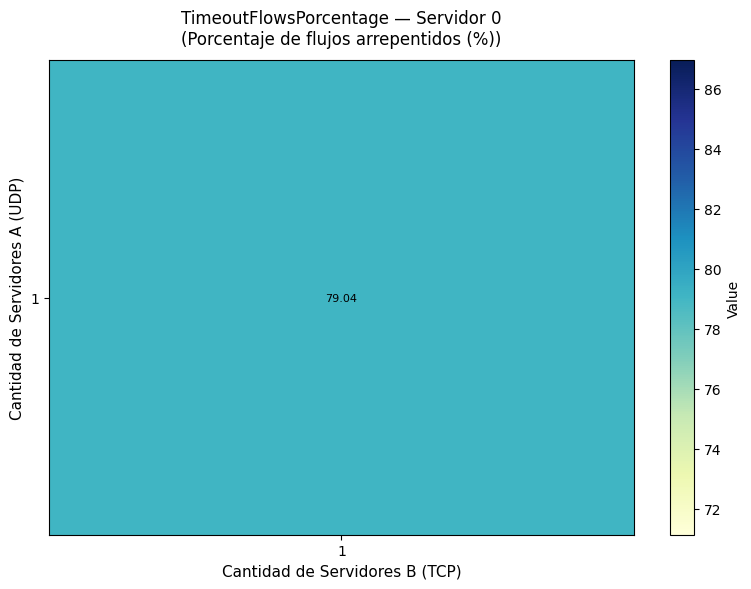

N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor A (%): 0.0319
N=1, M=1 [srv 0] | Promedio espera en cola servidor A (ms): 143639.9170
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor A (ms): 145814.9788
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 79.2138
N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0572
N=1, M=1 [srv 0] | Promedio espera en cola servidor B (ms): 135685.1131
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor B (ms): 137857.8103
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 79.2138
N=1, M=2 [srv 0] | Tiempo ocioso promedio servidor A (%): 5.3937
N=1, M=2 [srv 0] | Promedio espera en cola servidor A (ms): 6469.9056
N=1, M=2 [srv 0] | Promedio permanencia en sistema servidor A (ms): 7780.9556
N=1, M=2 [srv 0] | Porcentaje de flujos arrepentidos (%): 15.9309
N=1, M=2 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0050
N=1, M=2 [srv 0] | Promedio espera en cola servidor B (ms): 35119.5387
N=1, M=2 [srv 0] | 

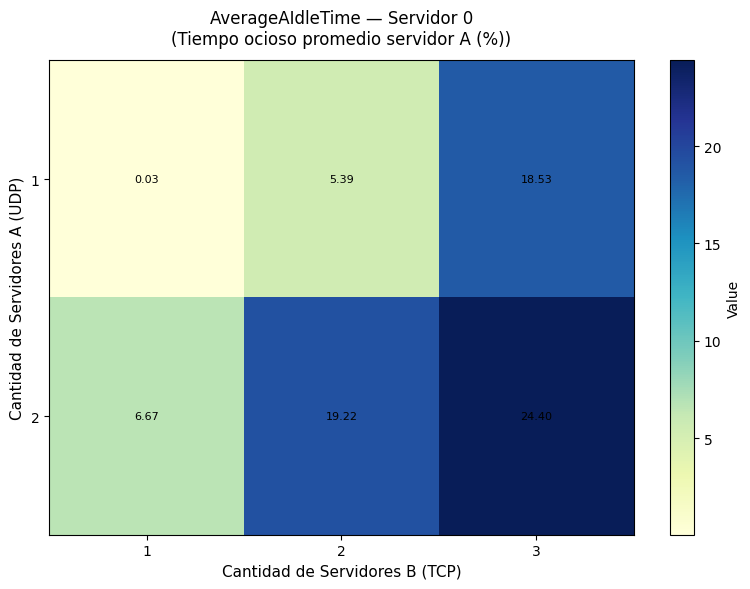


--- AverageAIdleTime [Servidor 1] ---
Mejor valor: 9.7823
-> N=2, M=1


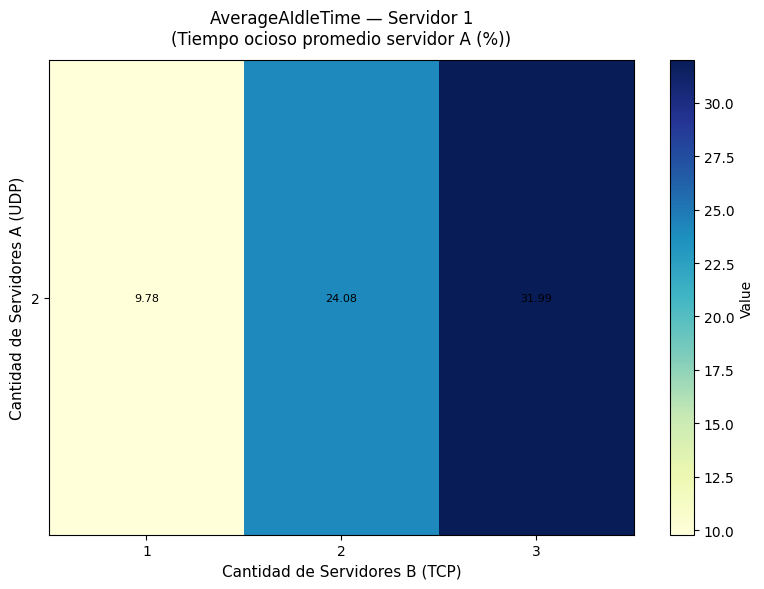


--- AverageAWaitTime [Servidor 0] ---
Mejor valor: 584.4144
-> N=2, M=3


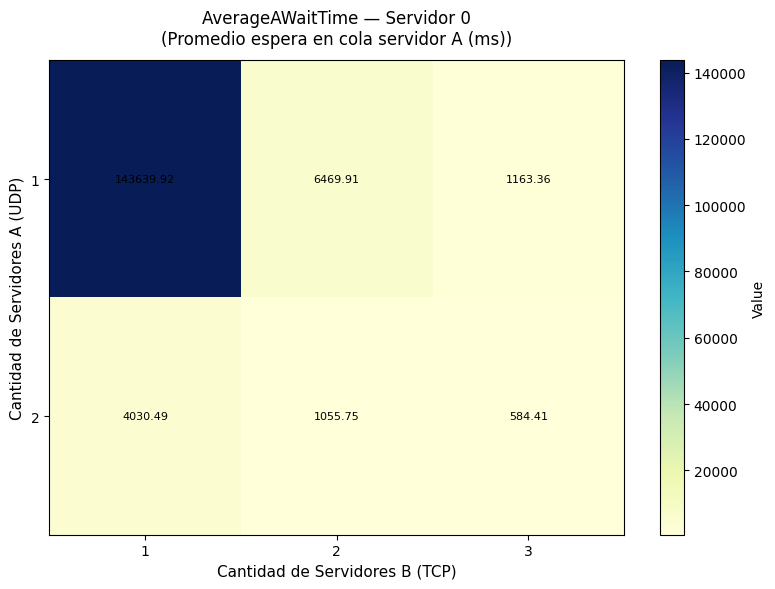


--- AverageAWaitTime [Servidor 1] ---
Mejor valor: 412.1272
-> N=2, M=3


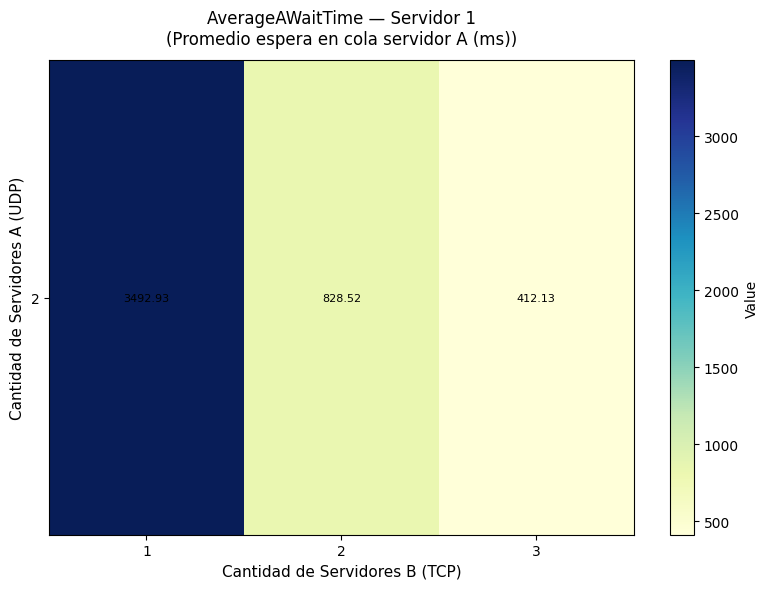


--- AverageAServiceTime [Servidor 0] ---
Mejor valor: 1539.4304
-> N=2, M=3


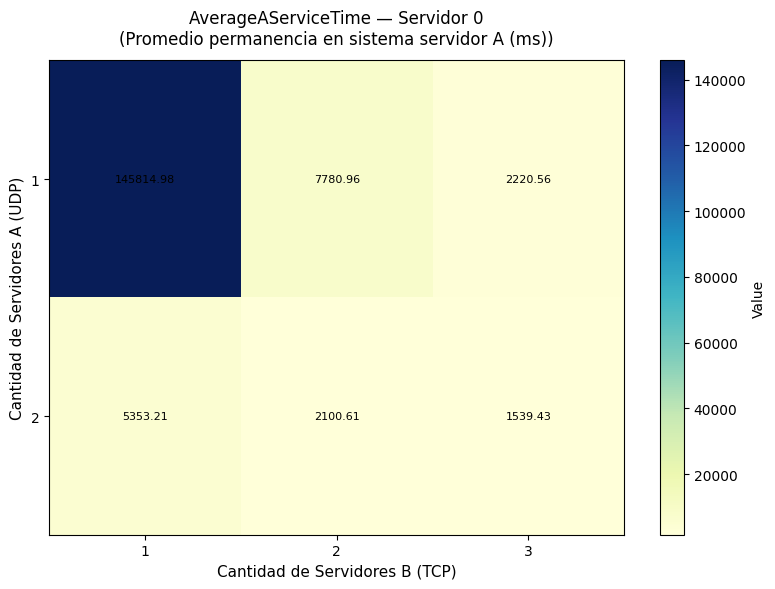


--- AverageAServiceTime [Servidor 1] ---
Mejor valor: 1271.2970
-> N=2, M=3


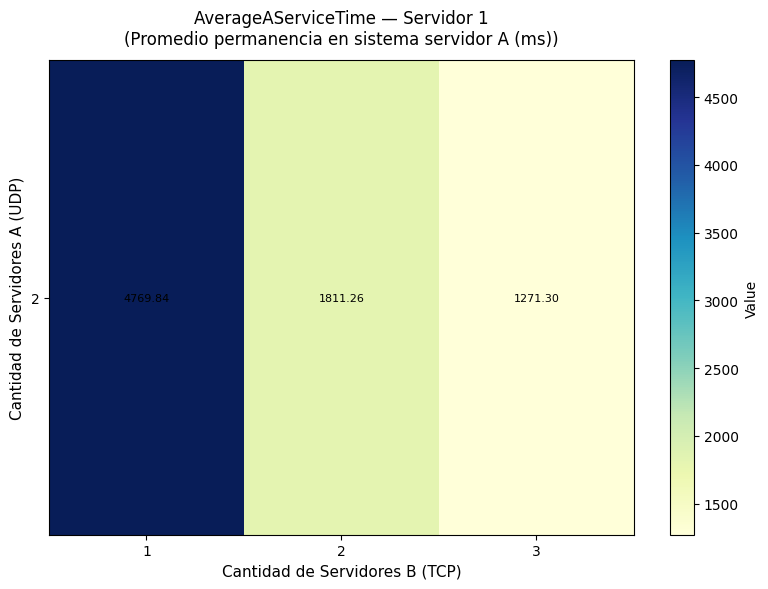


--- TimeoutFlowsPorcentage [Servidor 0] ---
Mejor valor: 0.0000
-> N=1, M=3
-> N=1, M=3
-> N=2, M=2
-> N=2, M=2
-> N=2, M=3
-> N=2, M=3


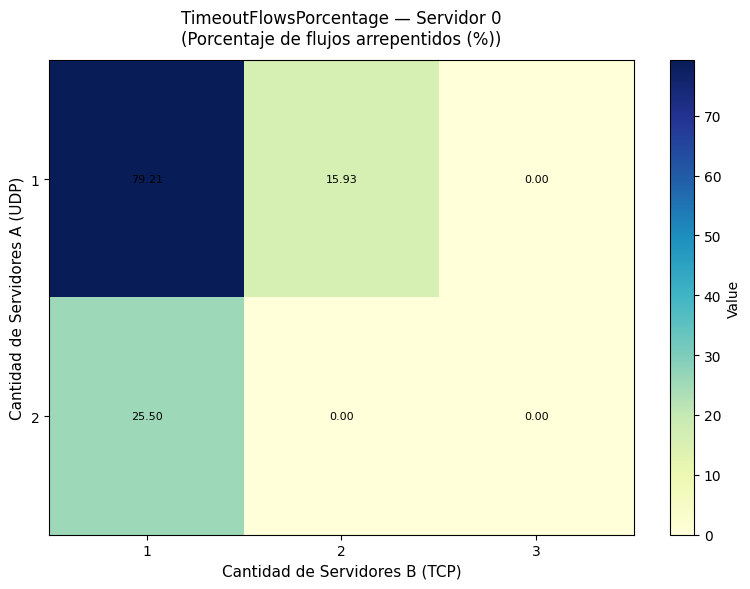


--- TimeoutFlowsPorcentage [Servidor 1] ---
Mejor valor: 0.0000
-> N=1, M=3
-> N=2, M=2
-> N=2, M=2
-> N=2, M=3
-> N=2, M=3


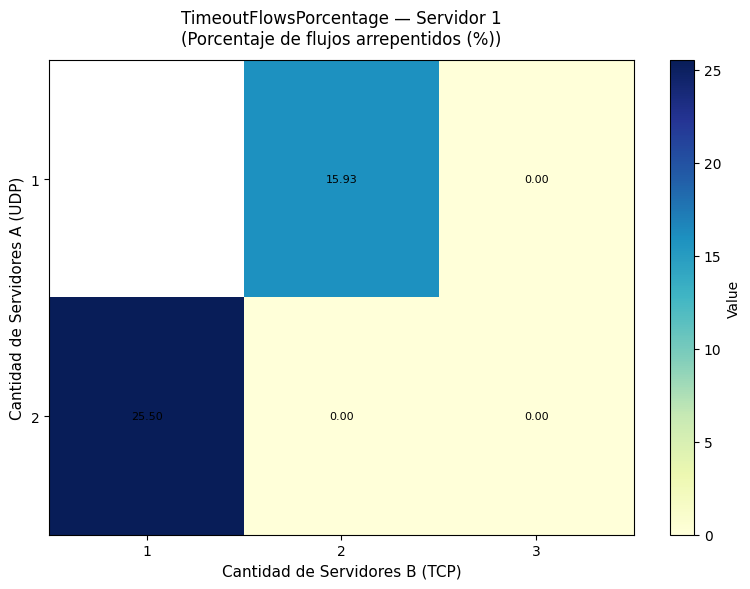


--- TimeoutFlowsPorcentage [Servidor 2] ---
Mejor valor: 0.0000
-> N=1, M=3
-> N=2, M=3


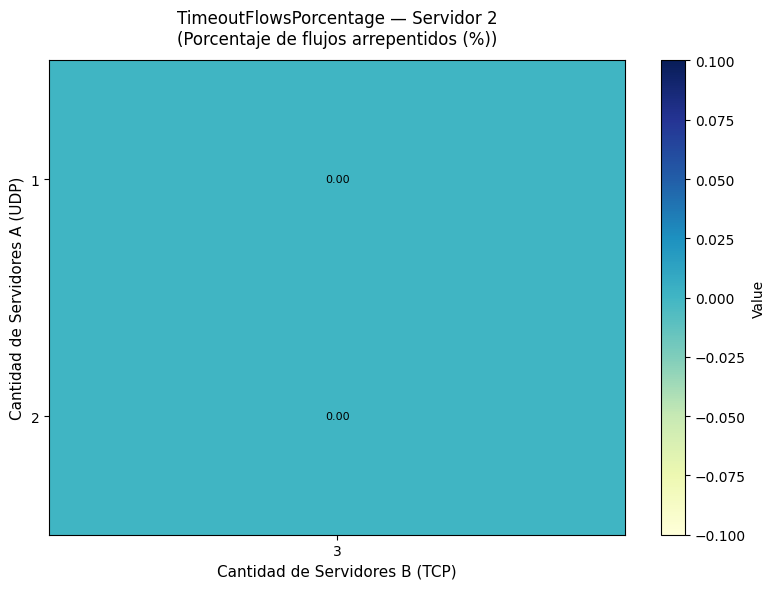


--- AverageBIdleTime [Servidor 0] ---
Mejor valor: 0.0050
-> N=1, M=2


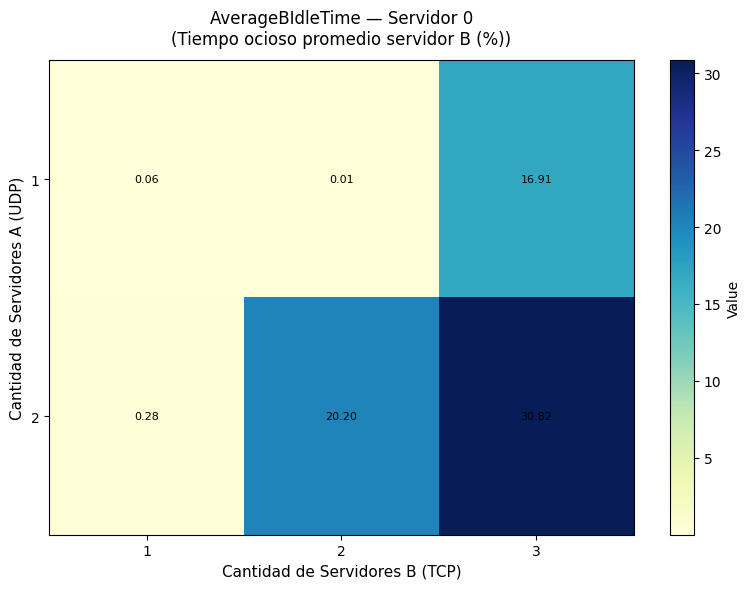


--- AverageBIdleTime [Servidor 1] ---
Mejor valor: 0.0344
-> N=1, M=2


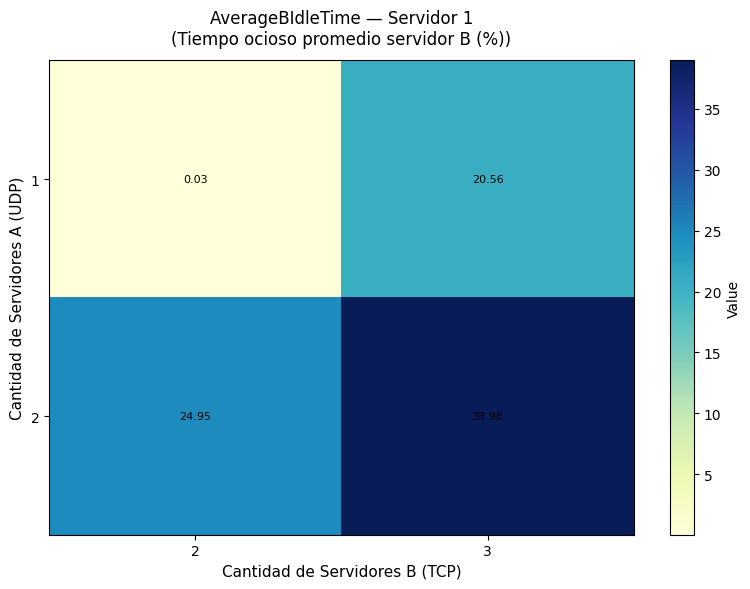


--- AverageBIdleTime [Servidor 2] ---
Mejor valor: 26.9693
-> N=1, M=3


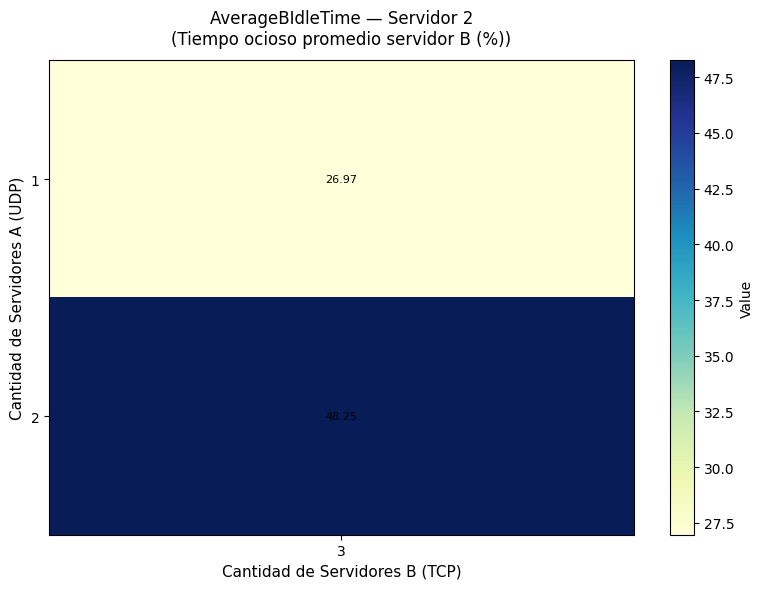


--- AverageBWaitTime [Servidor 0] ---
Mejor valor: 584.9654
-> N=2, M=3


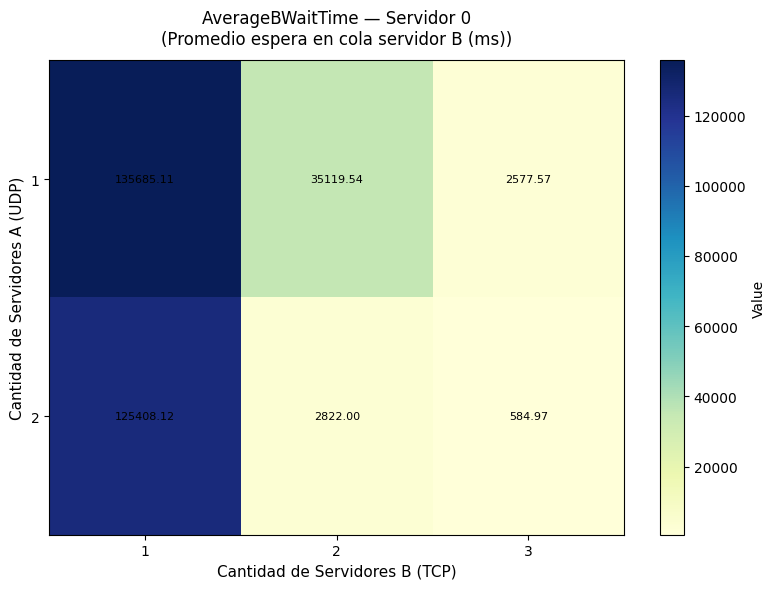


--- AverageBWaitTime [Servidor 1] ---
Mejor valor: 534.1180
-> N=2, M=3


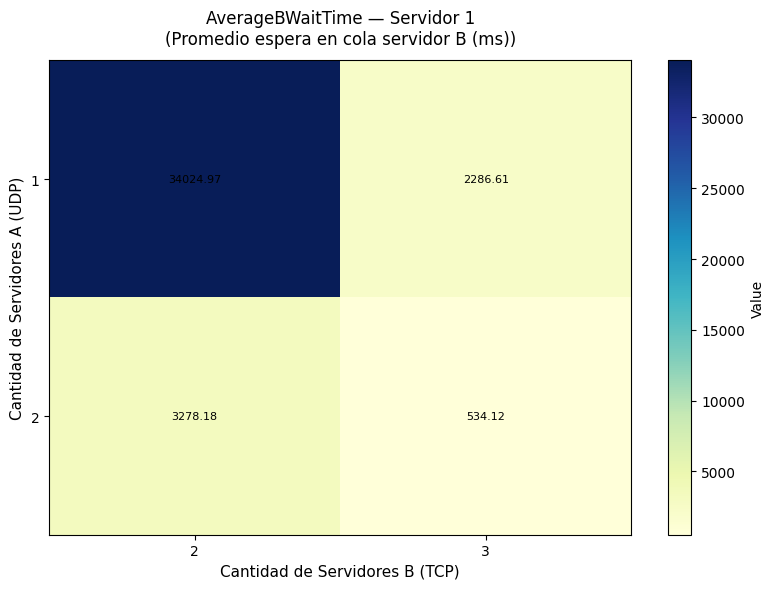


--- AverageBWaitTime [Servidor 2] ---
Mejor valor: 503.5862
-> N=2, M=3


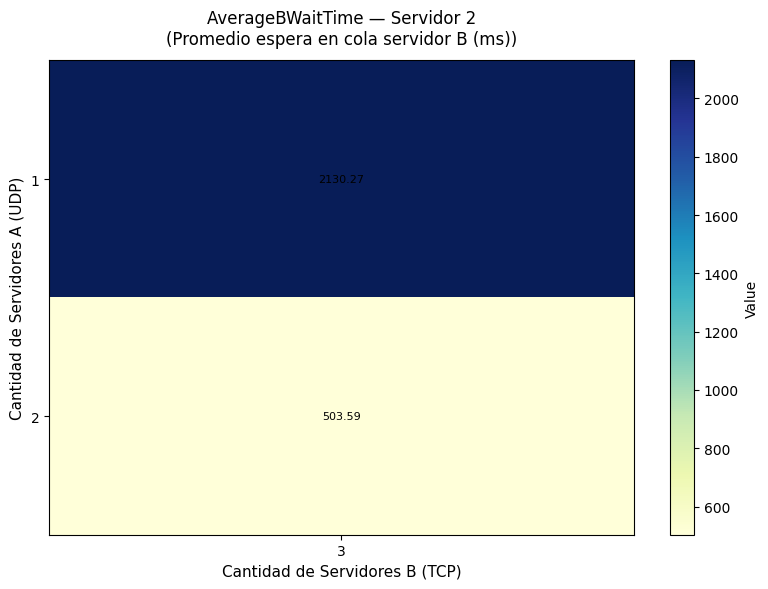


--- AverageBServiceTime [Servidor 0] ---
Mejor valor: 1458.8926
-> N=2, M=3


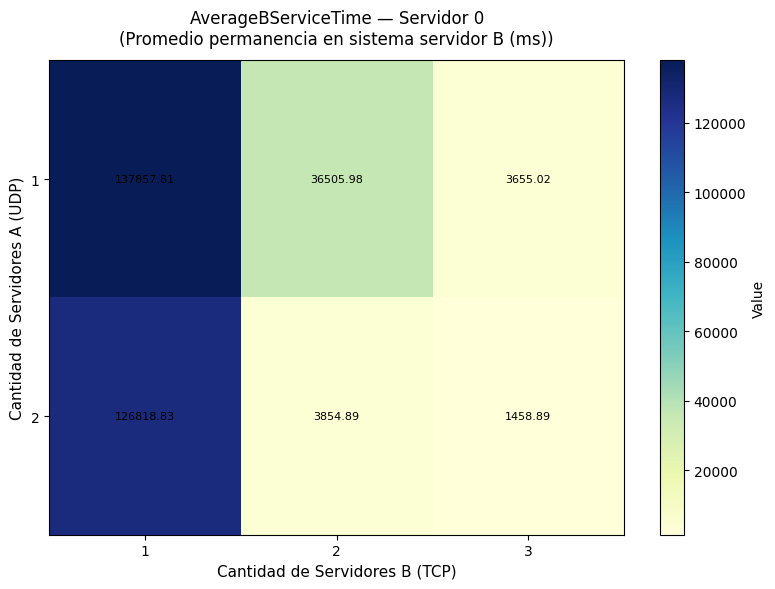


--- AverageBServiceTime [Servidor 1] ---
Mejor valor: 1304.9969
-> N=2, M=3


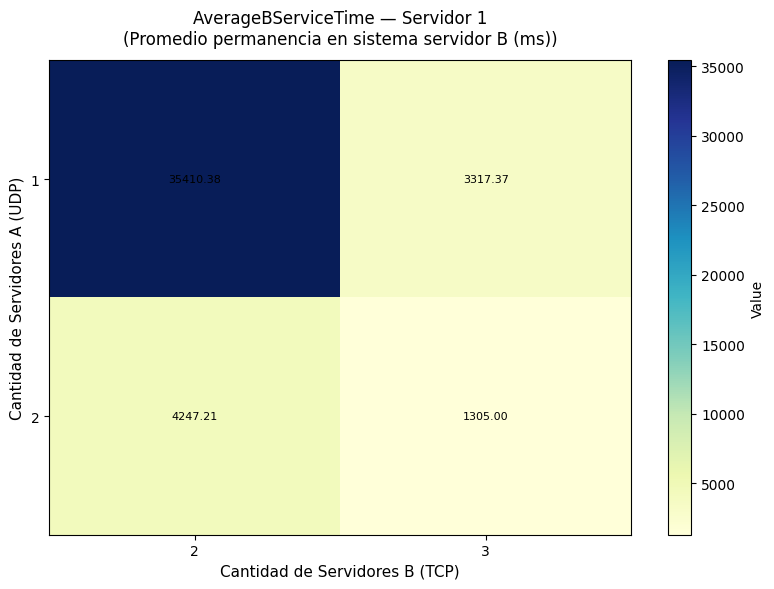


--- AverageBServiceTime [Servidor 2] ---
Mejor valor: 1157.3637
-> N=2, M=3


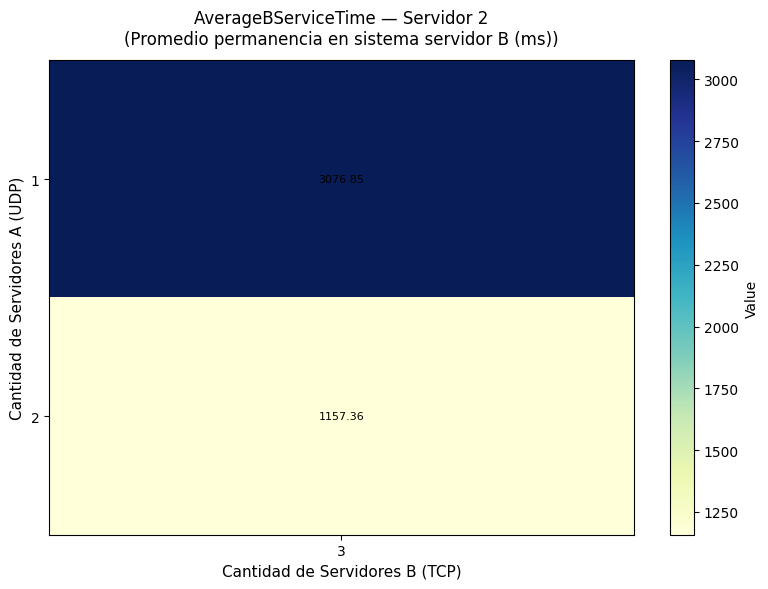

N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor A (%): 0.4795
N=1, M=1 [srv 0] | Promedio espera en cola servidor A (ms): 81085.2939
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor A (ms): 83020.8195
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 76.2810
N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0000
N=1, M=1 [srv 0] | Promedio espera en cola servidor B (ms): 85658.7469
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor B (ms): 87617.8320
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 76.2810
N=1, M=2 [srv 0] | Tiempo ocioso promedio servidor A (%): 6.4221
N=1, M=2 [srv 0] | Promedio espera en cola servidor A (ms): 4530.7096
N=1, M=2 [srv 0] | Promedio permanencia en sistema servidor A (ms): 5834.7045
N=1, M=2 [srv 0] | Porcentaje de flujos arrepentidos (%): 22.2504
N=1, M=2 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0848
N=1, M=2 [srv 0] | Promedio espera en cola servidor B (ms): 70399.0809
N=1, M=2 [srv 0] | Prom

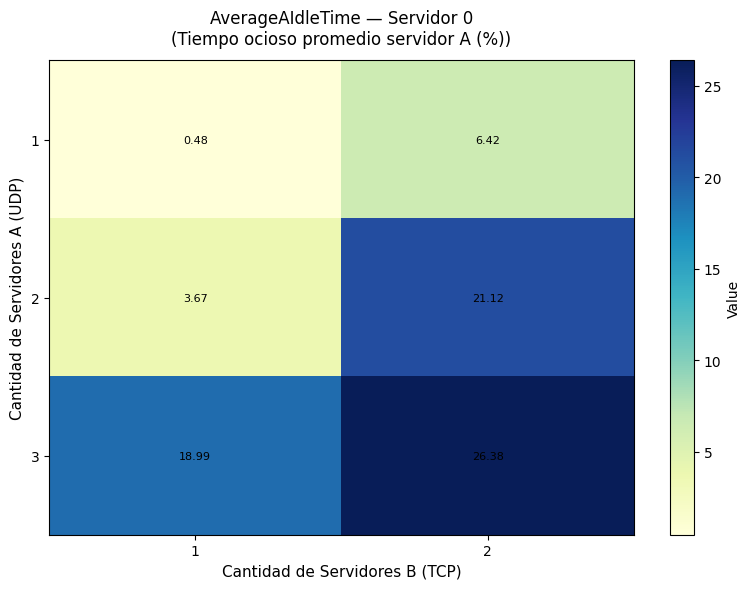


--- AverageAIdleTime [Servidor 1] ---
Mejor valor: 6.6474
-> N=2, M=1


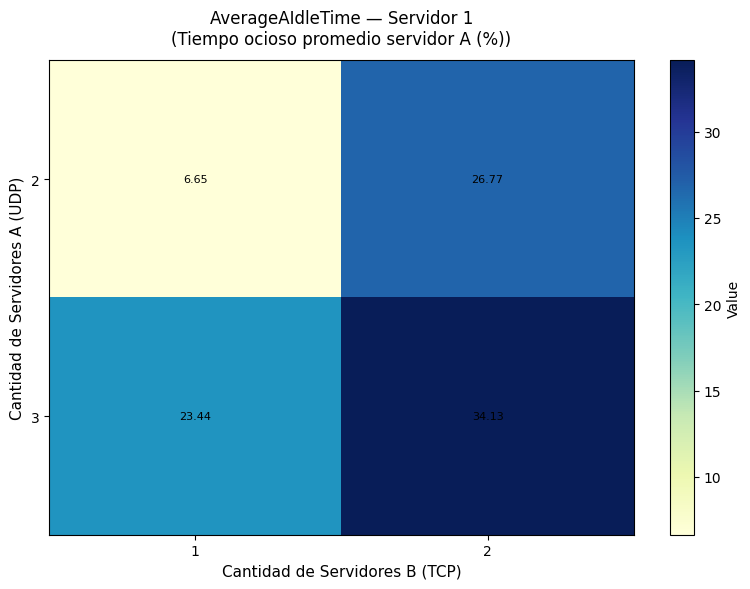


--- AverageAIdleTime [Servidor 2] ---
Mejor valor: 29.6368
-> N=3, M=1


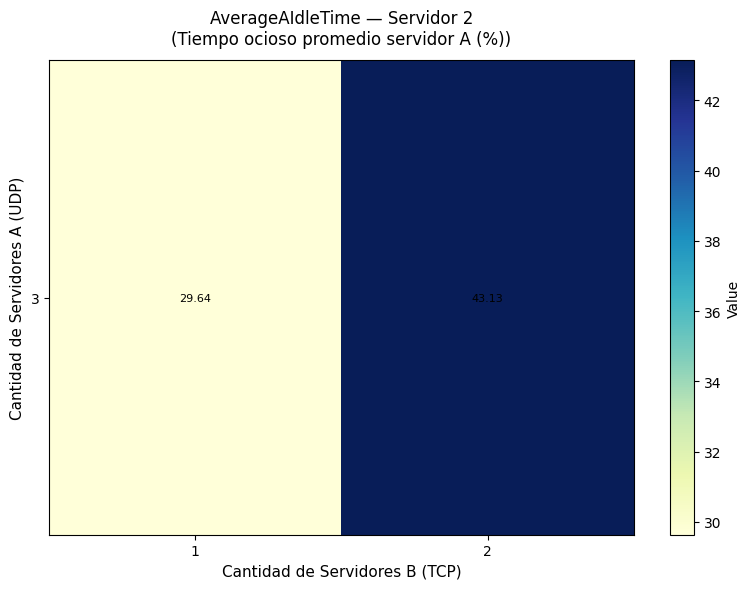


--- AverageAWaitTime [Servidor 0] ---
Mejor valor: 562.7815
-> N=3, M=2


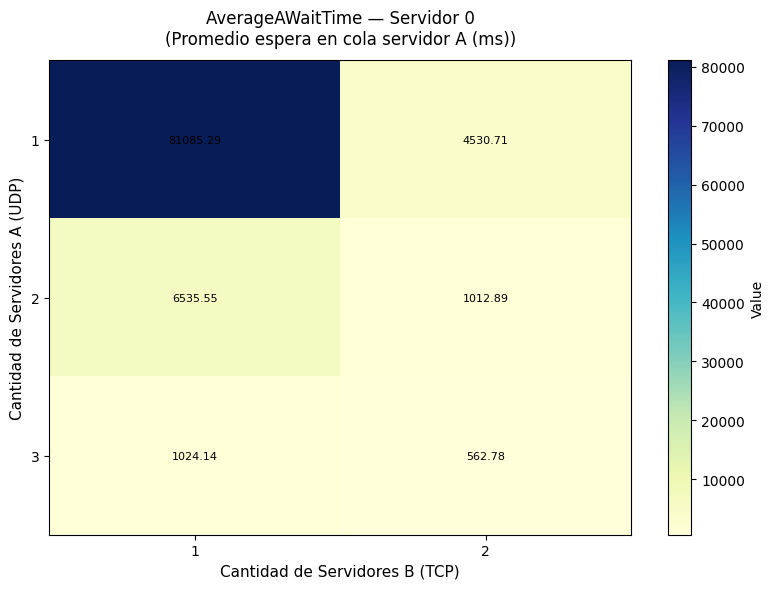


--- AverageAWaitTime [Servidor 1] ---
Mejor valor: 373.4192
-> N=3, M=2


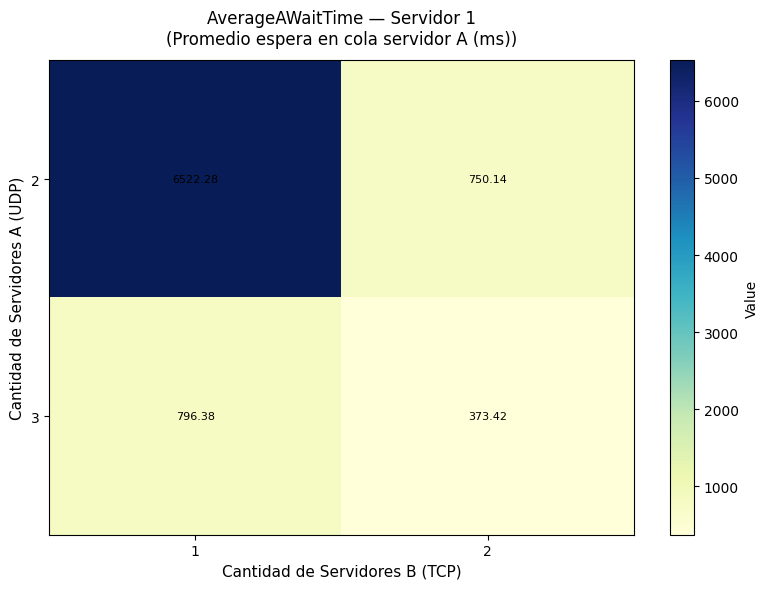


--- AverageAWaitTime [Servidor 2] ---
Mejor valor: 293.1952
-> N=3, M=2


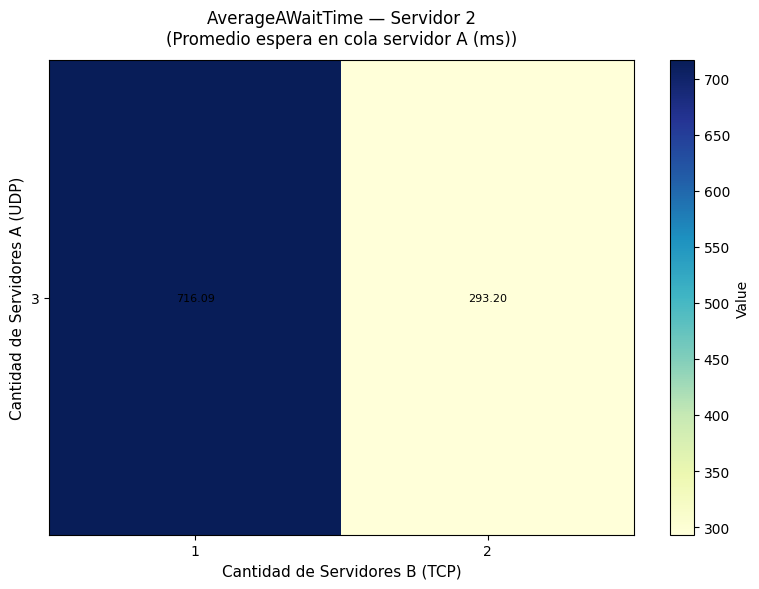


--- AverageAServiceTime [Servidor 0] ---
Mejor valor: 1524.0404
-> N=3, M=2


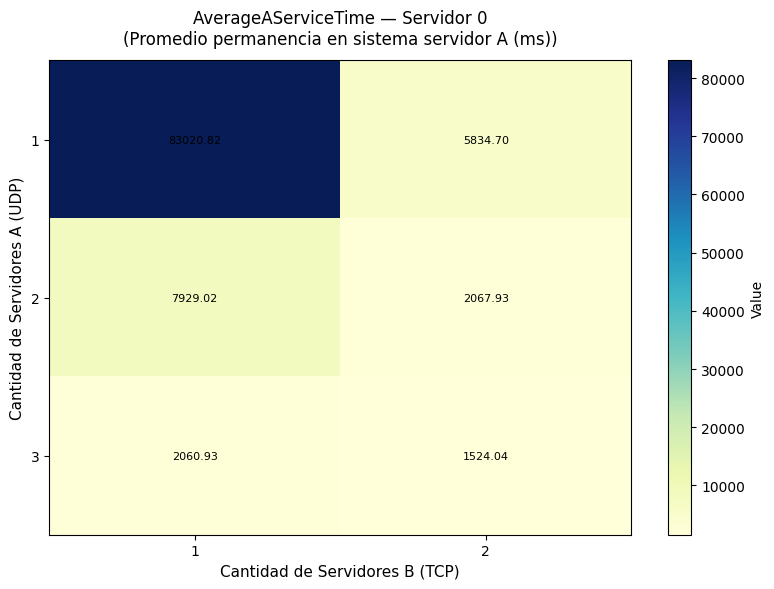


--- AverageAServiceTime [Servidor 1] ---
Mejor valor: 1233.5995
-> N=3, M=2


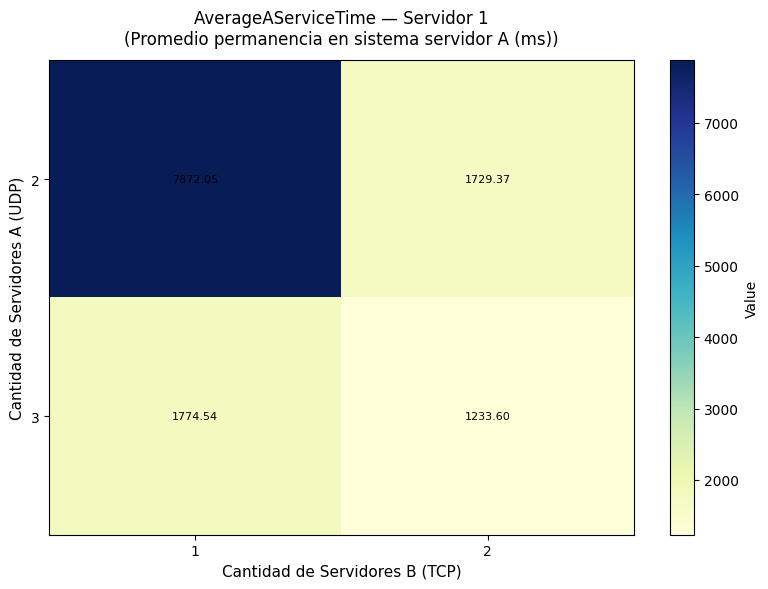


--- AverageAServiceTime [Servidor 2] ---
Mejor valor: 1036.1811
-> N=3, M=2


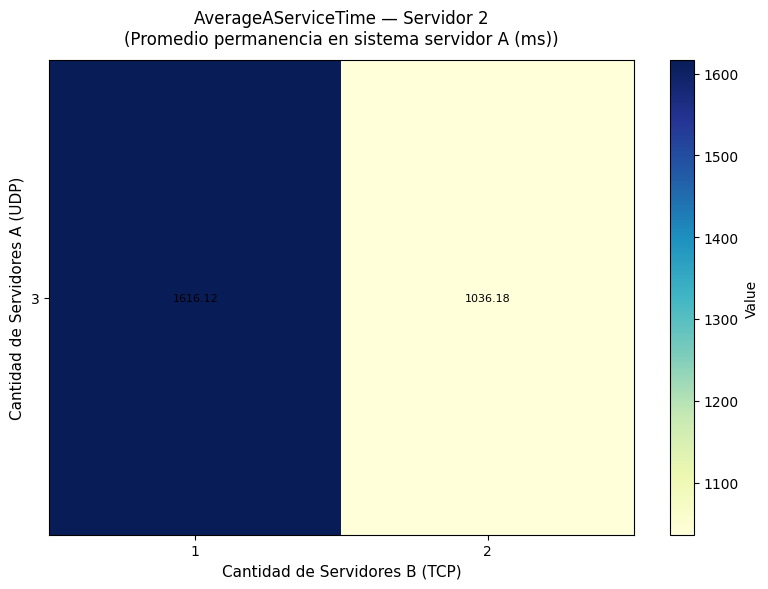


--- TimeoutFlowsPorcentage [Servidor 0] ---
Mejor valor: 0.0000
-> N=2, M=2
-> N=2, M=2
-> N=3, M=1
-> N=3, M=1
-> N=3, M=2
-> N=3, M=2


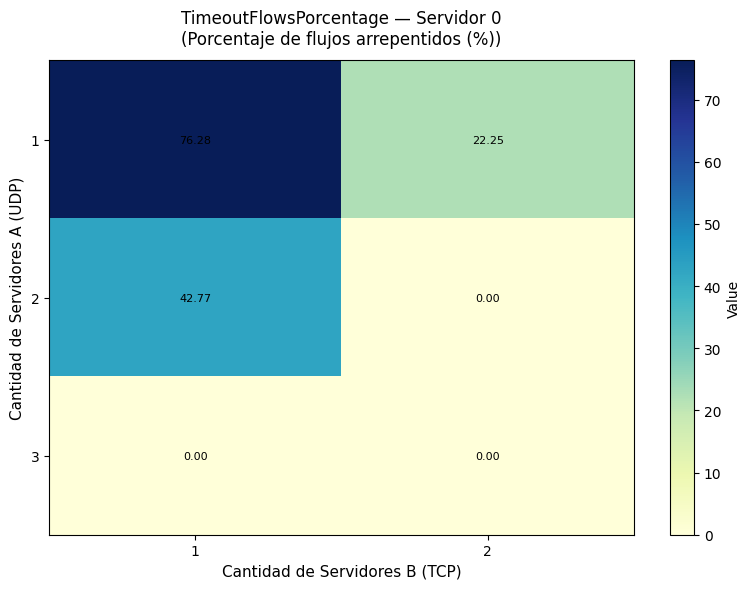


--- TimeoutFlowsPorcentage [Servidor 1] ---
Mejor valor: 0.0000
-> N=2, M=2
-> N=2, M=2
-> N=3, M=1
-> N=3, M=2
-> N=3, M=2


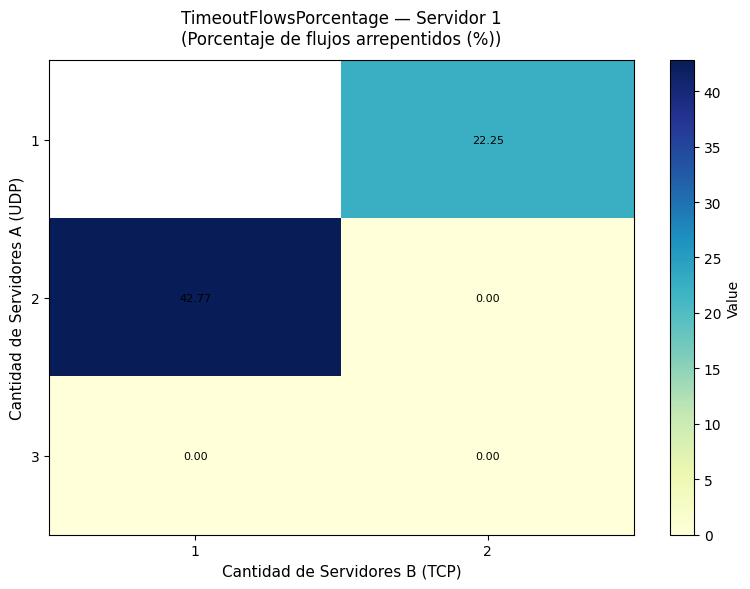


--- TimeoutFlowsPorcentage [Servidor 2] ---
Mejor valor: 0.0000
-> N=3, M=1
-> N=3, M=2


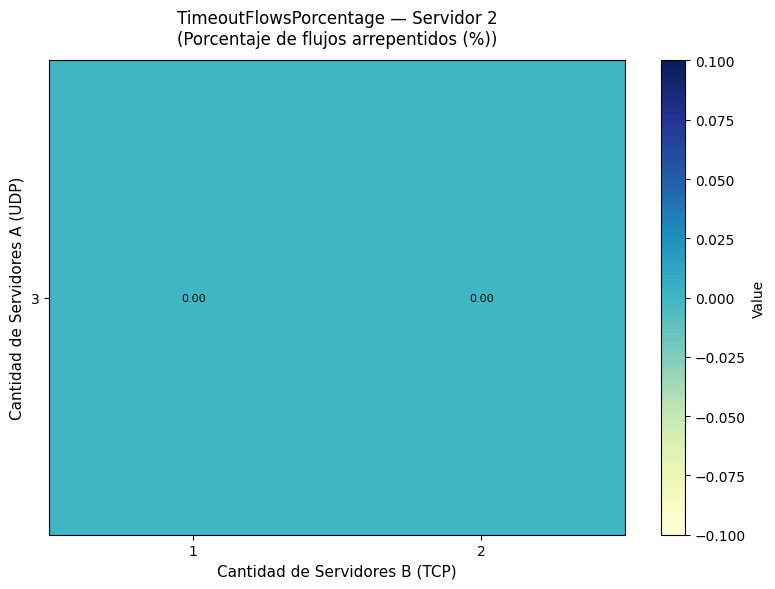


--- AverageBIdleTime [Servidor 0] ---
Mejor valor: 0.0000
-> N=1, M=1


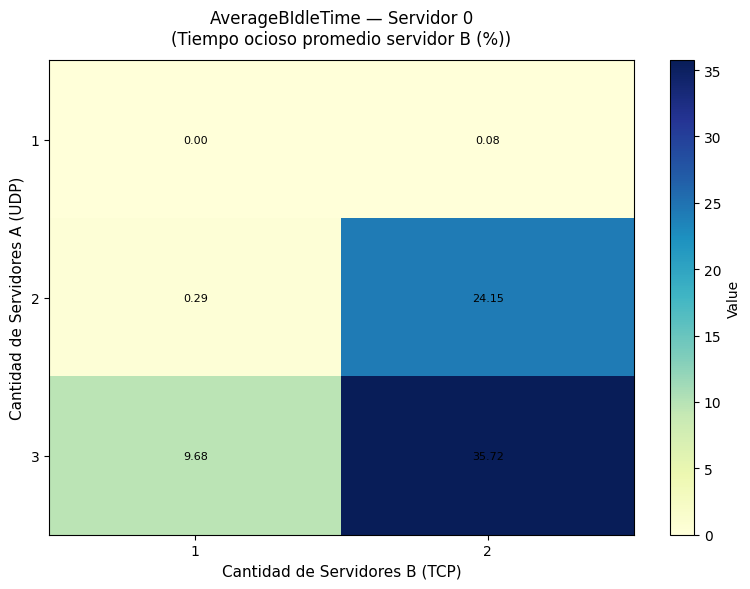


--- AverageBIdleTime [Servidor 1] ---
Mejor valor: 0.1324
-> N=1, M=2


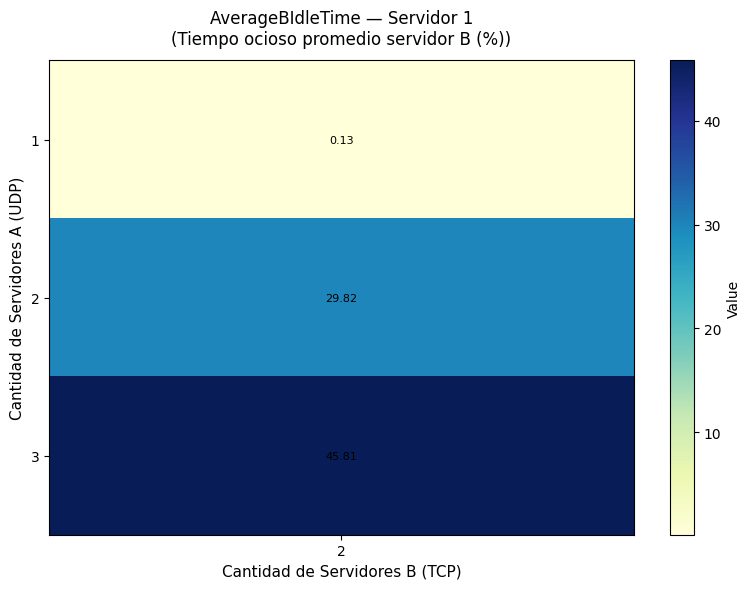


--- AverageBWaitTime [Servidor 0] ---
Mejor valor: 866.3990
-> N=3, M=2


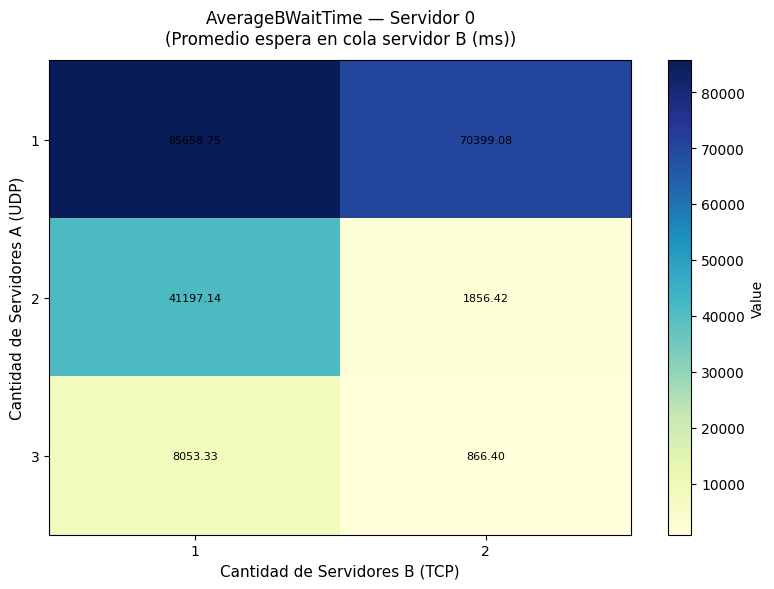


--- AverageBWaitTime [Servidor 1] ---
Mejor valor: 644.3452
-> N=3, M=2


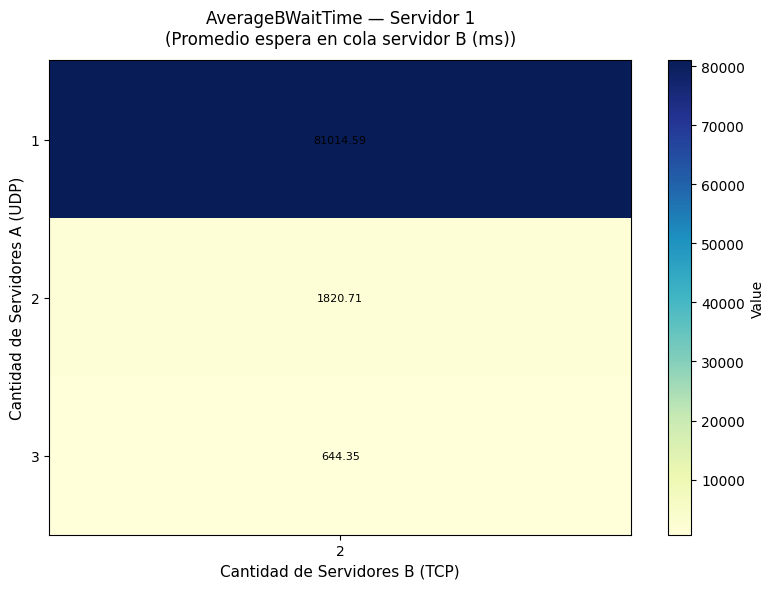


--- AverageBServiceTime [Servidor 0] ---
Mejor valor: 1705.2974
-> N=3, M=2


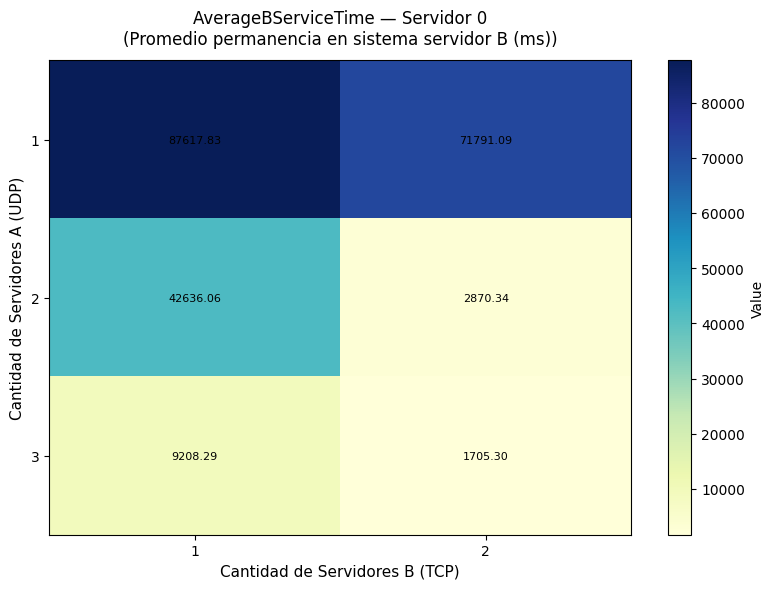


--- AverageBServiceTime [Servidor 1] ---
Mejor valor: 1352.7908
-> N=3, M=2


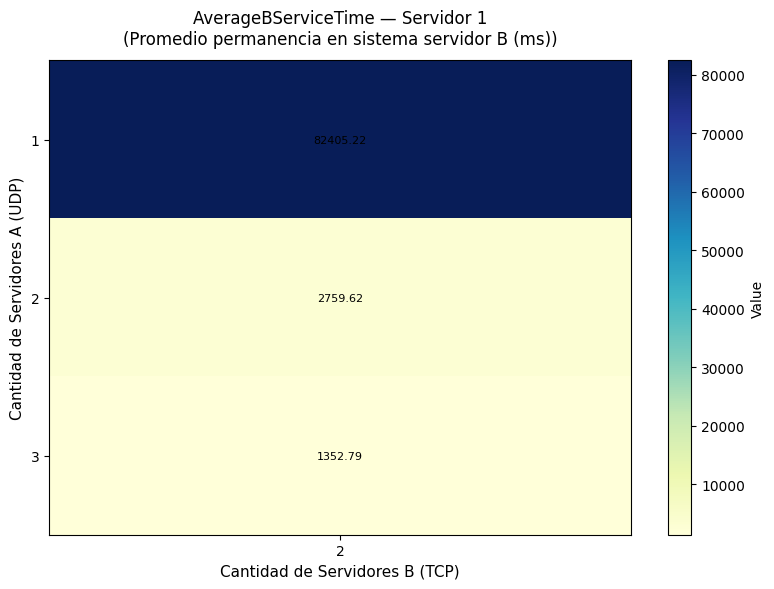

N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor A (%): 0.0121
N=1, M=1 [srv 0] | Promedio espera en cola servidor A (ms): 102374.8133
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor A (ms): 104513.3235
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 78.4815
N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0000
N=1, M=1 [srv 0] | Promedio espera en cola servidor B (ms): 113499.1934
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor B (ms): 115631.2269
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 78.4815
N=2, M=1 [srv 0] | Tiempo ocioso promedio servidor A (%): 6.2879
N=2, M=1 [srv 0] | Promedio espera en cola servidor A (ms): 5615.6346
N=2, M=1 [srv 0] | Promedio permanencia en sistema servidor A (ms): 6940.8702
N=2, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 31.6828
N=2, M=1 [srv 1] | Tiempo ocioso promedio servidor A (%): 8.5460
N=2, M=1 [srv 1] | Promedio espera en cola servidor A (ms): 5408.6624
N=2, M=1 [srv 1] | P

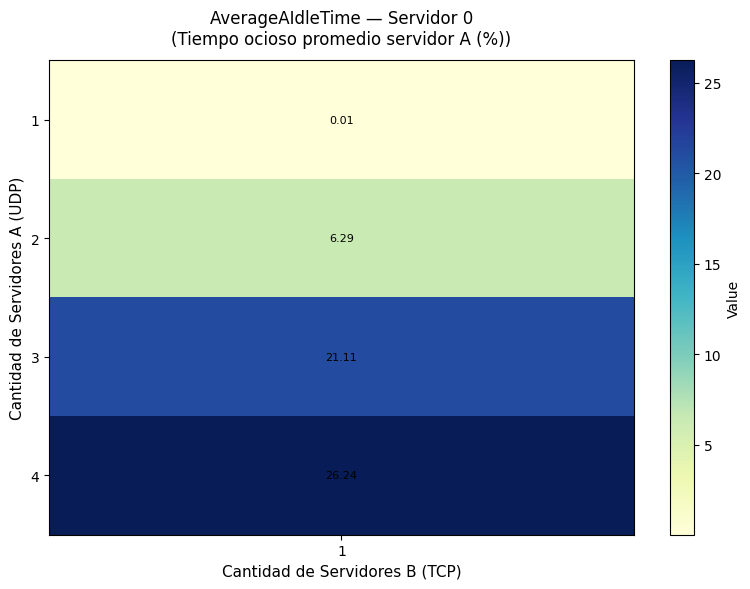


--- AverageAIdleTime [Servidor 1] ---
Mejor valor: 8.5460
-> N=2, M=1


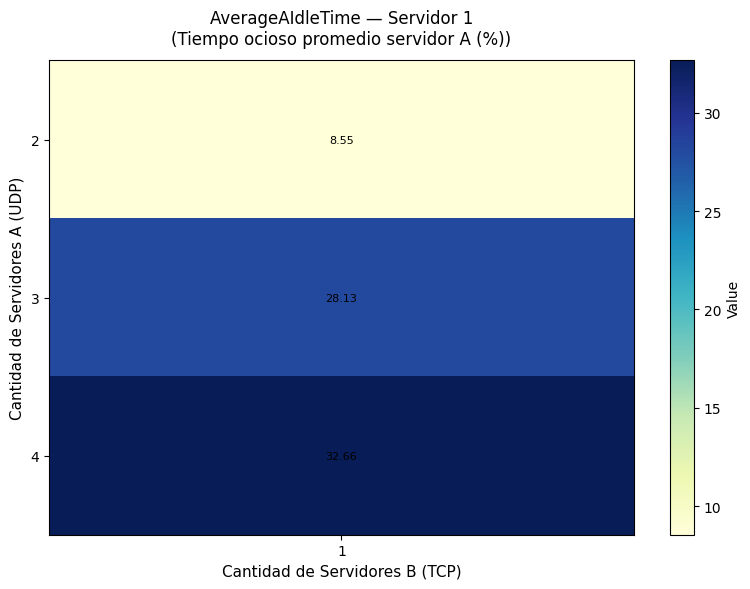


--- AverageAIdleTime [Servidor 2] ---
Mejor valor: 35.3395
-> N=3, M=1


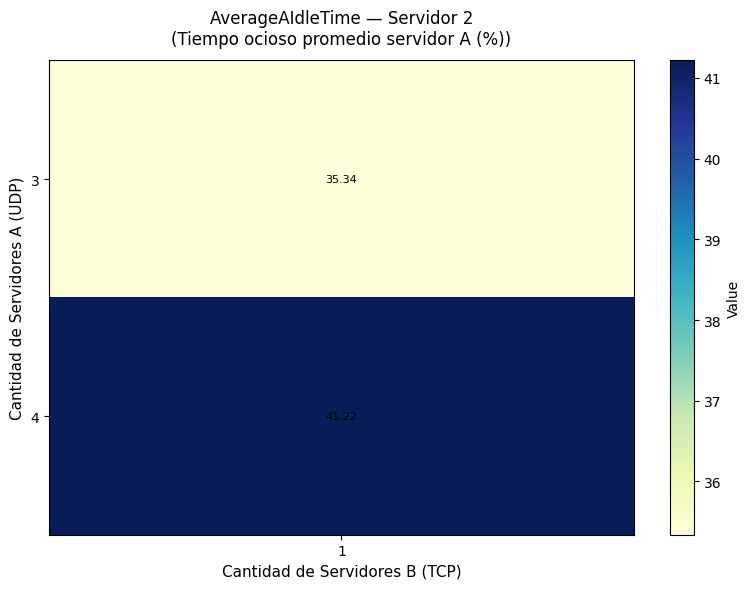


--- AverageAWaitTime [Servidor 0] ---
Mejor valor: 576.0514
-> N=4, M=1


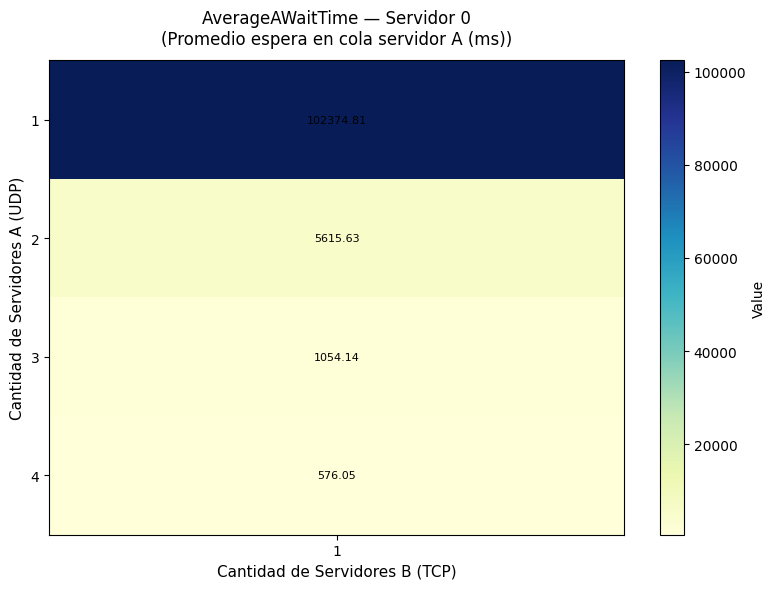


--- AverageAWaitTime [Servidor 1] ---
Mejor valor: 397.9676
-> N=4, M=1


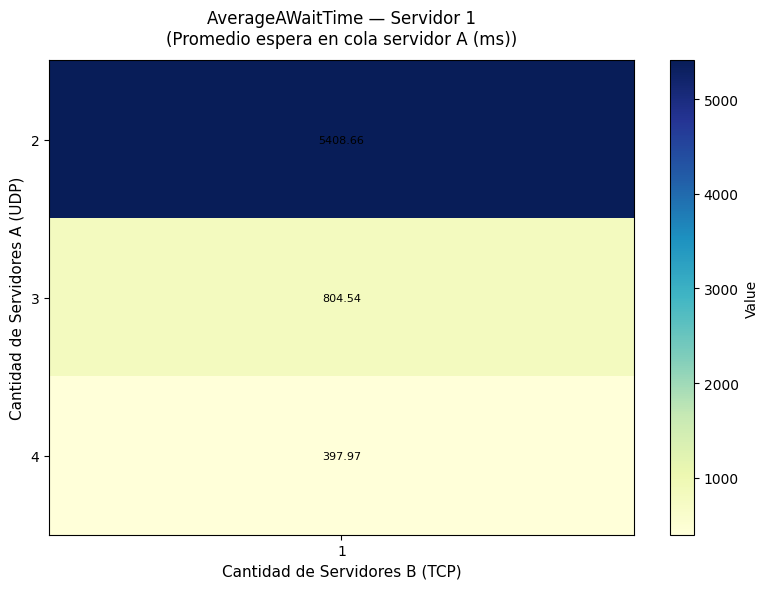


--- AverageAWaitTime [Servidor 2] ---
Mejor valor: 338.5288
-> N=4, M=1


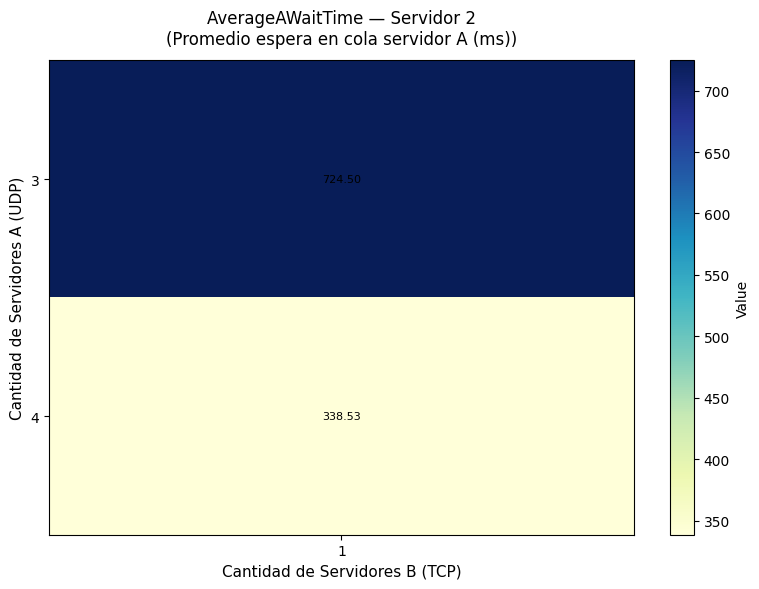


--- AverageAServiceTime [Servidor 0] ---
Mejor valor: 1515.5479
-> N=4, M=1


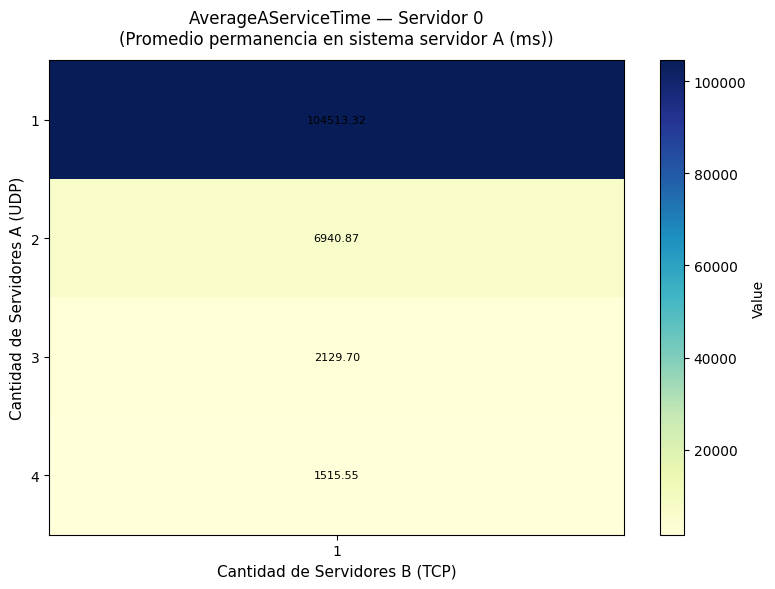


--- AverageAServiceTime [Servidor 1] ---
Mejor valor: 1255.6501
-> N=4, M=1


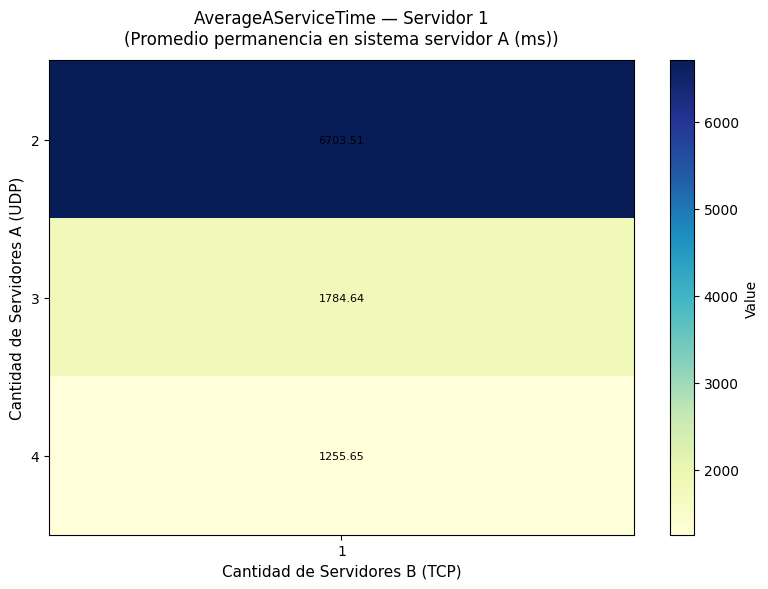


--- AverageAServiceTime [Servidor 2] ---
Mejor valor: 1087.3512
-> N=4, M=1


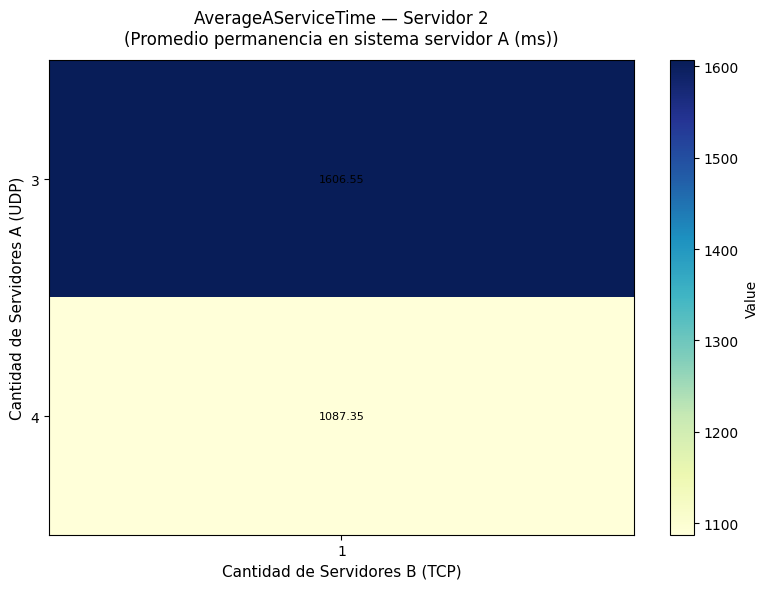


--- TimeoutFlowsPorcentage [Servidor 0] ---
Mejor valor: 0.0000
-> N=3, M=1
-> N=3, M=1
-> N=4, M=1
-> N=4, M=1


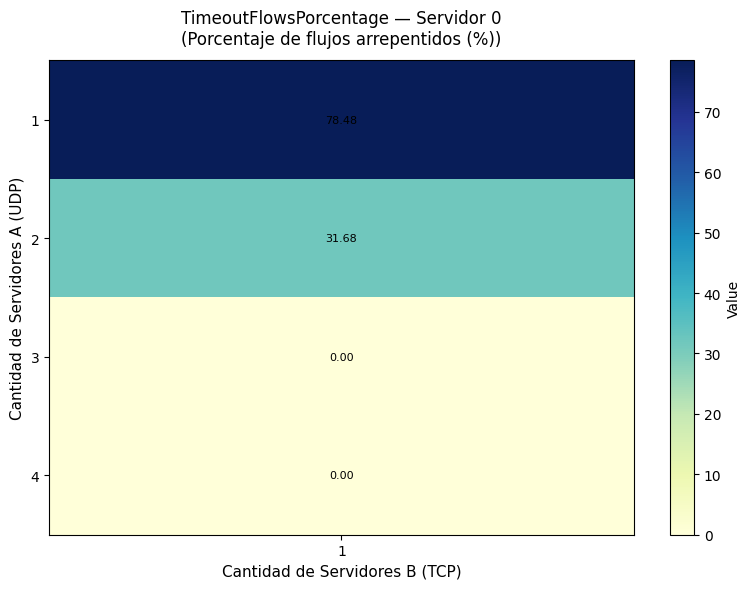


--- TimeoutFlowsPorcentage [Servidor 1] ---
Mejor valor: 0.0000
-> N=3, M=1
-> N=4, M=1


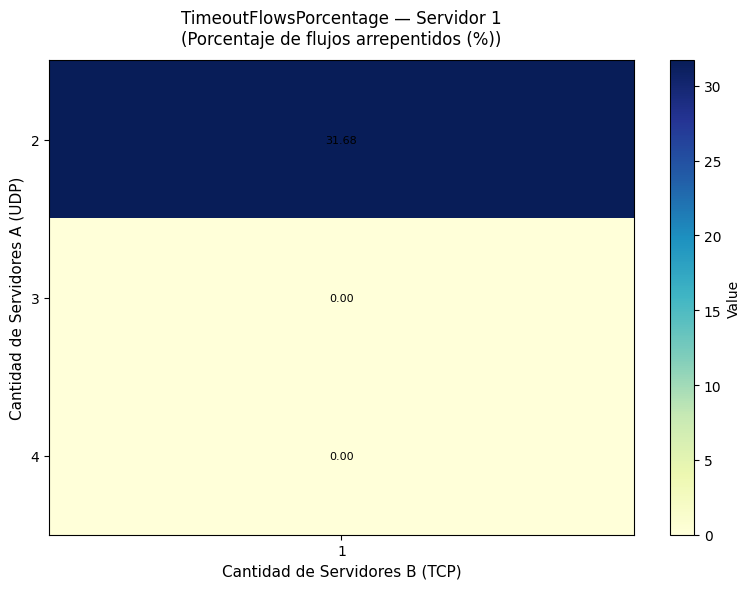


--- TimeoutFlowsPorcentage [Servidor 2] ---
Mejor valor: 0.0000
-> N=3, M=1
-> N=4, M=1


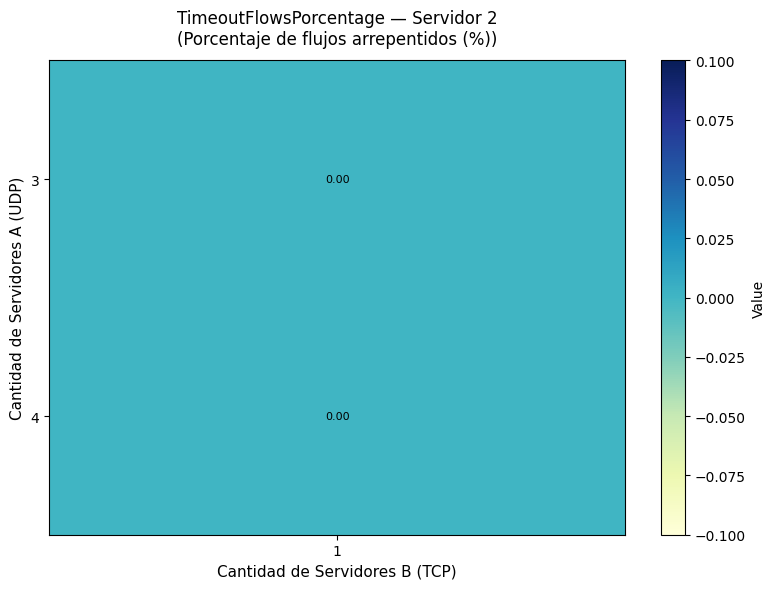


--- AverageBIdleTime [Servidor 0] ---
Mejor valor: 0.0000
-> N=1, M=1


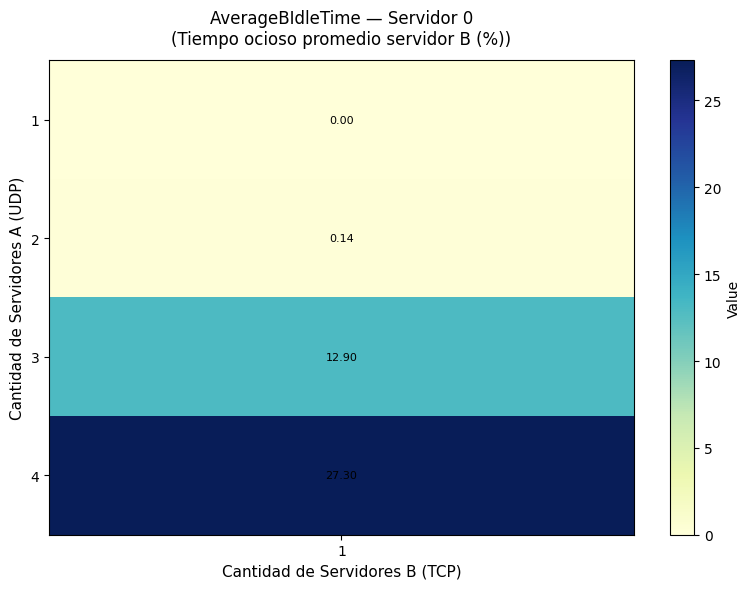


--- AverageBWaitTime [Servidor 0] ---
Mejor valor: 2384.5558
-> N=4, M=1


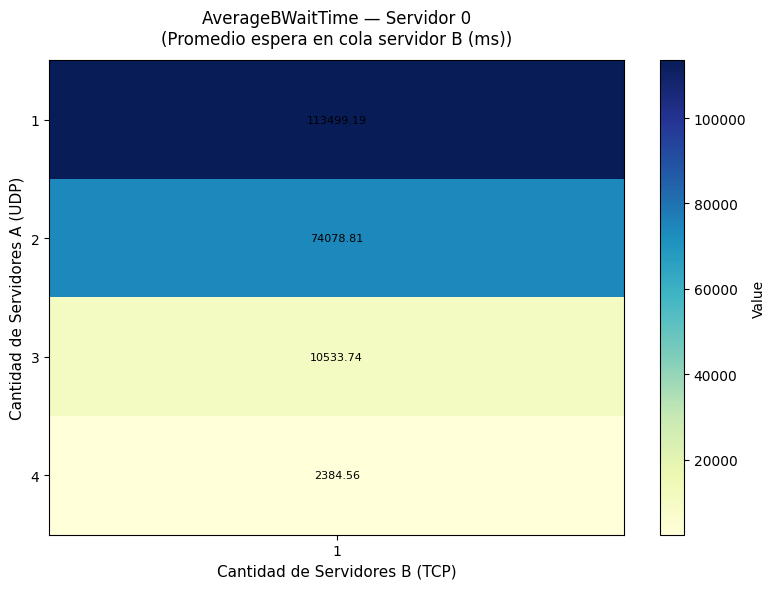


--- AverageBServiceTime [Servidor 0] ---
Mejor valor: 3312.0367
-> N=4, M=1


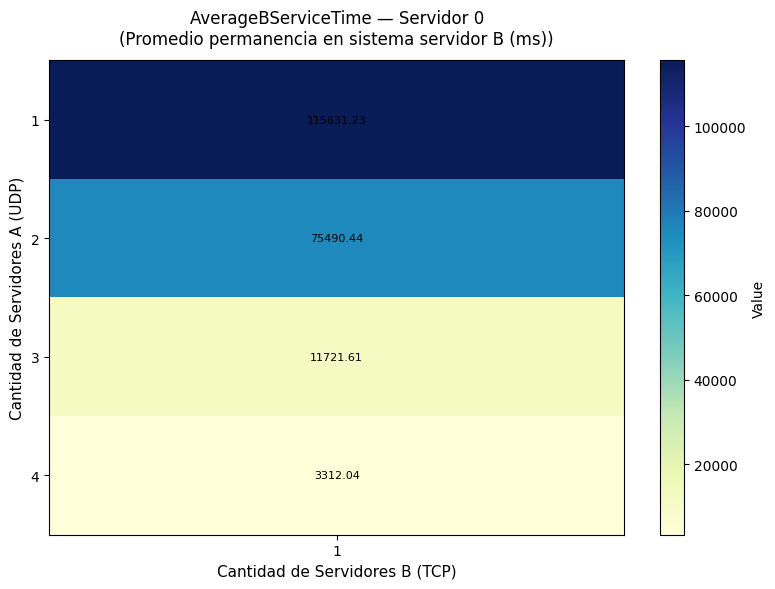

N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor A (%): 0.4121
N=1, M=1 [srv 0] | Promedio espera en cola servidor A (ms): 108901.0129
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor A (ms): 111019.5327
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 77.2170
N=1, M=1 [srv 0] | Tiempo ocioso promedio servidor B (%): 0.0954
N=1, M=1 [srv 0] | Promedio espera en cola servidor B (ms): 112517.2295
N=1, M=1 [srv 0] | Promedio permanencia en sistema servidor B (ms): 114650.6063
N=1, M=1 [srv 0] | Porcentaje de flujos arrepentidos (%): 77.2170
N=1, M=2 [srv 0] | Tiempo ocioso promedio servidor A (%): 4.9848
N=1, M=2 [srv 0] | Promedio espera en cola servidor A (ms): 8401.6522
N=1, M=2 [srv 0] | Promedio permanencia en sistema servidor A (ms): 9792.5456
N=1, M=2 [srv 0] | Porcentaje de flujos arrepentidos (%): 36.8442
N=1, M=2 [srv 0] | Tiempo ocioso promedio servidor B (%): 2.5507
N=1, M=2 [srv 0] | Promedio espera en cola servidor B (ms): 43070.3531
N=1, M=2 [srv 0] | 

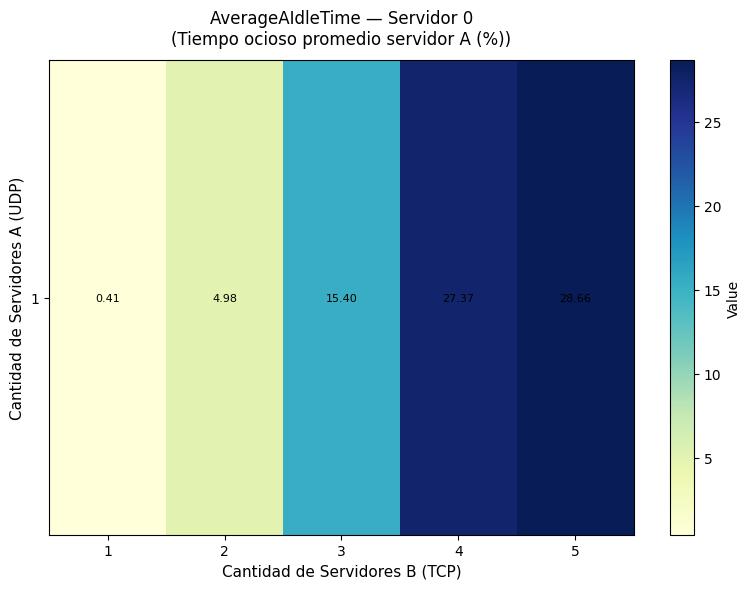


--- AverageAWaitTime [Servidor 0] ---
Mejor valor: 422.5570
-> N=1, M=5


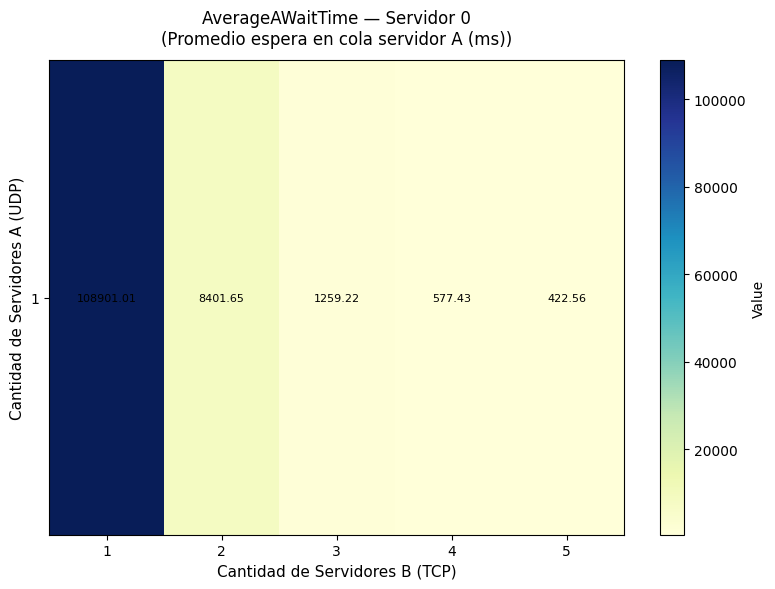


--- AverageAServiceTime [Servidor 0] ---
Mejor valor: 1337.9445
-> N=1, M=5


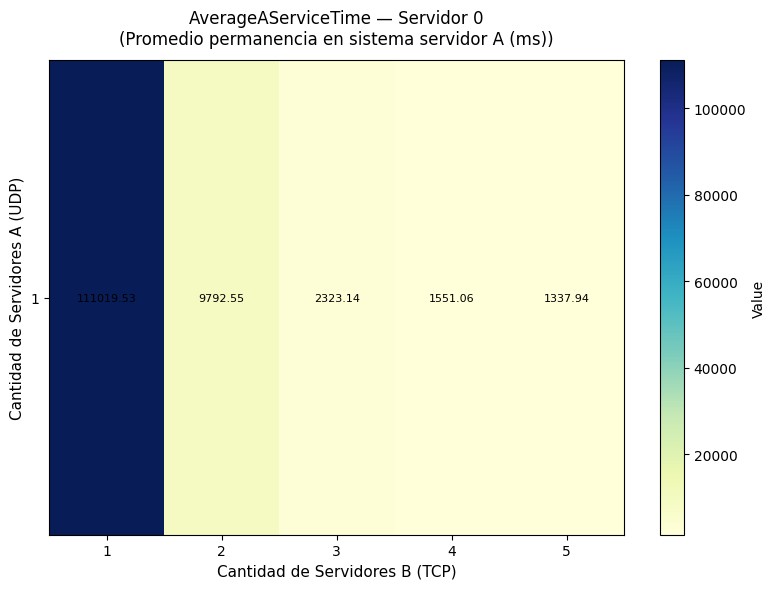


--- TimeoutFlowsPorcentage [Servidor 0] ---
Mejor valor: 0.0000
-> N=1, M=3
-> N=1, M=3
-> N=1, M=4
-> N=1, M=4
-> N=1, M=5
-> N=1, M=5


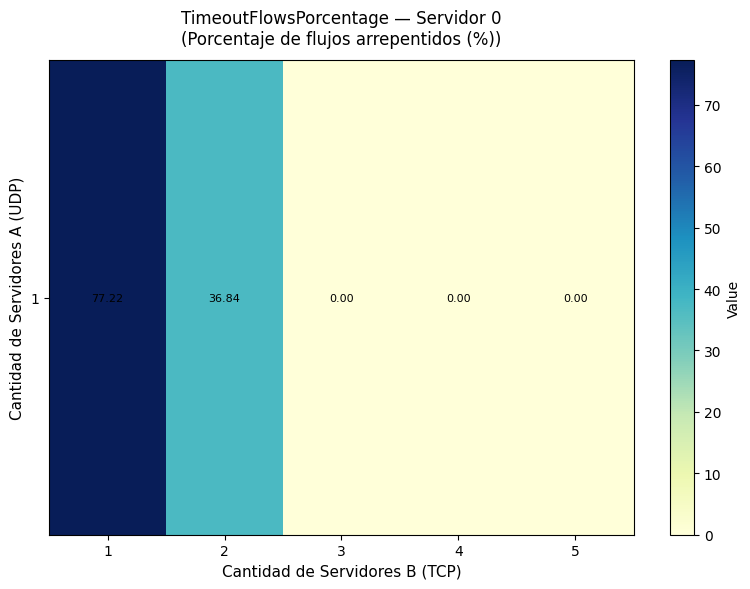


--- TimeoutFlowsPorcentage [Servidor 1] ---
Mejor valor: 0.0000
-> N=1, M=3
-> N=1, M=4
-> N=1, M=5


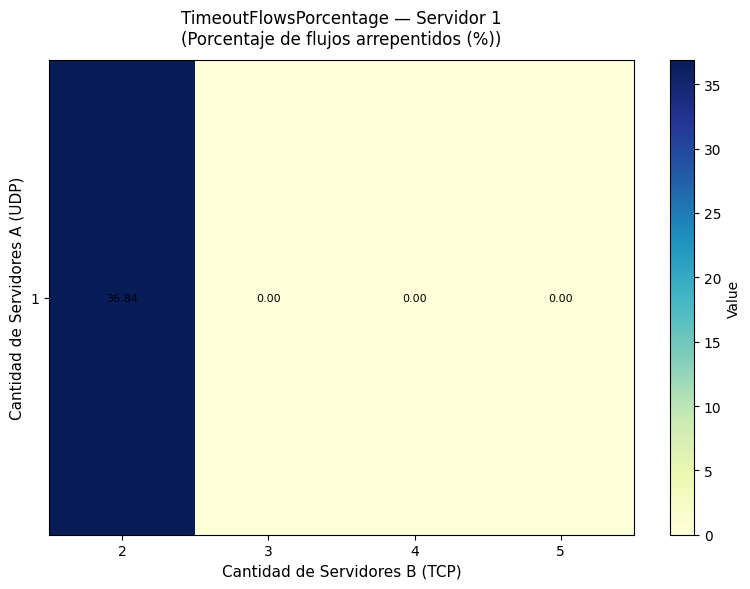


--- TimeoutFlowsPorcentage [Servidor 2] ---
Mejor valor: 0.0000
-> N=1, M=3
-> N=1, M=4
-> N=1, M=5


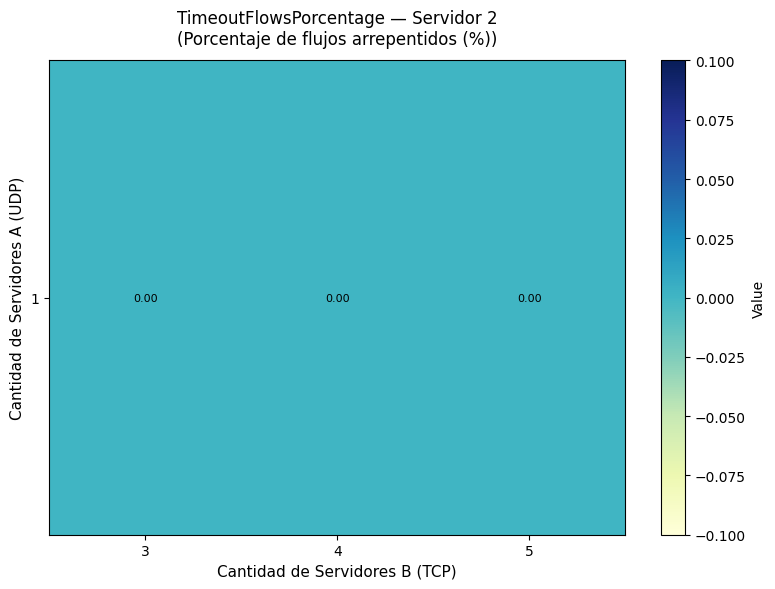


--- TimeoutFlowsPorcentage [Servidor 3] ---
Mejor valor: 0.0000
-> N=1, M=4
-> N=1, M=5


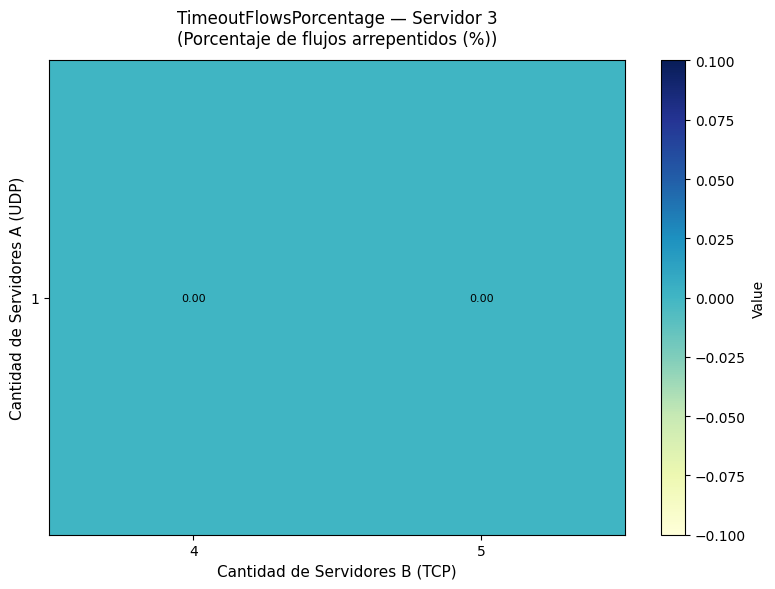


--- AverageBIdleTime [Servidor 0] ---
Mejor valor: 0.0954
-> N=1, M=1


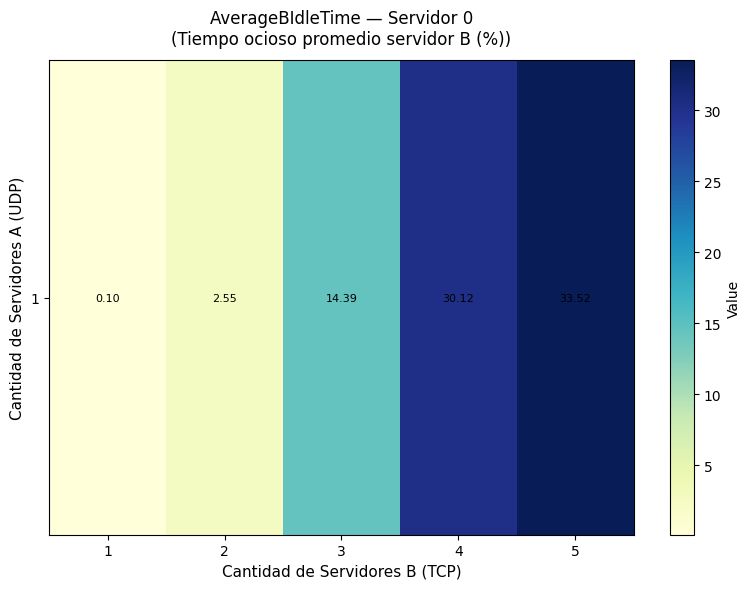


--- AverageBIdleTime [Servidor 1] ---
Mejor valor: 2.2806
-> N=1, M=2


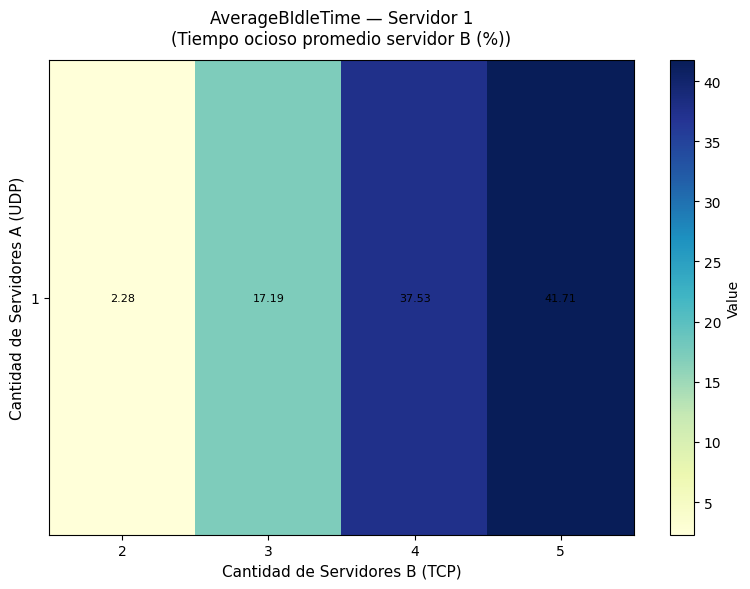


--- AverageBIdleTime [Servidor 2] ---
Mejor valor: 22.8416
-> N=1, M=3


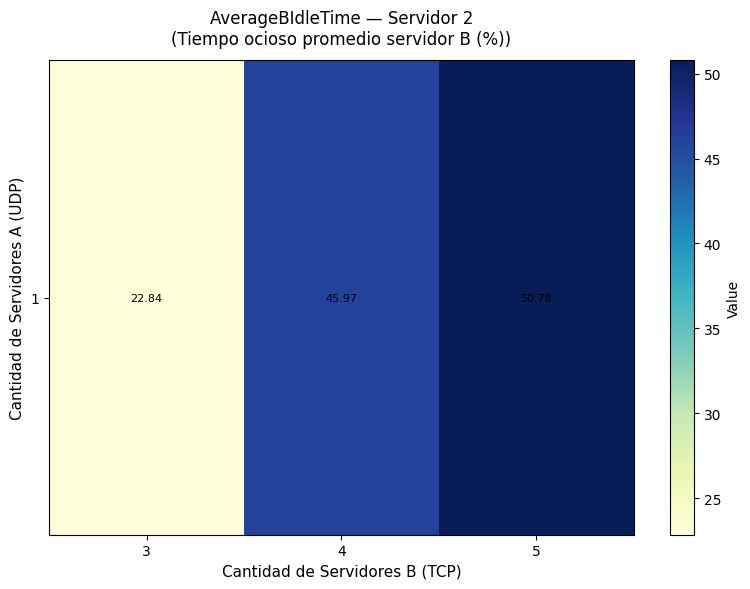


--- AverageBIdleTime [Servidor 3] ---
Mejor valor: 54.0506
-> N=1, M=4


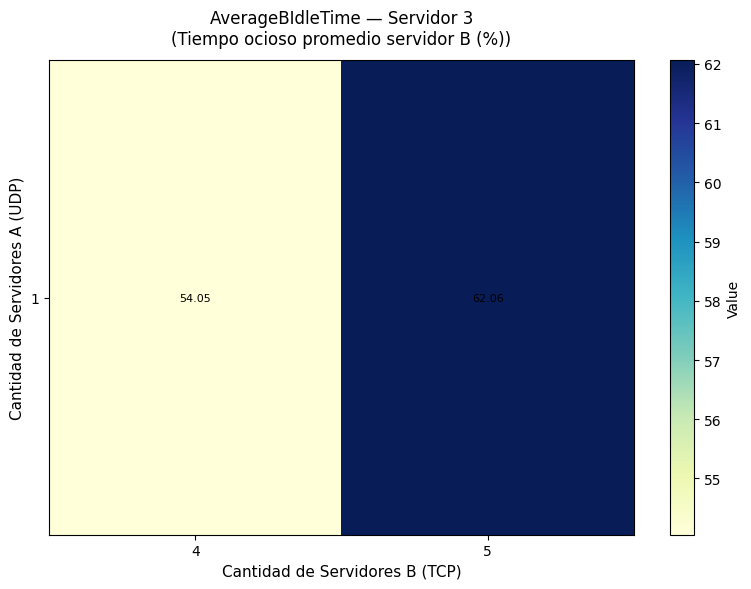


--- AverageBWaitTime [Servidor 0] ---
Mejor valor: 308.9799
-> N=1, M=5


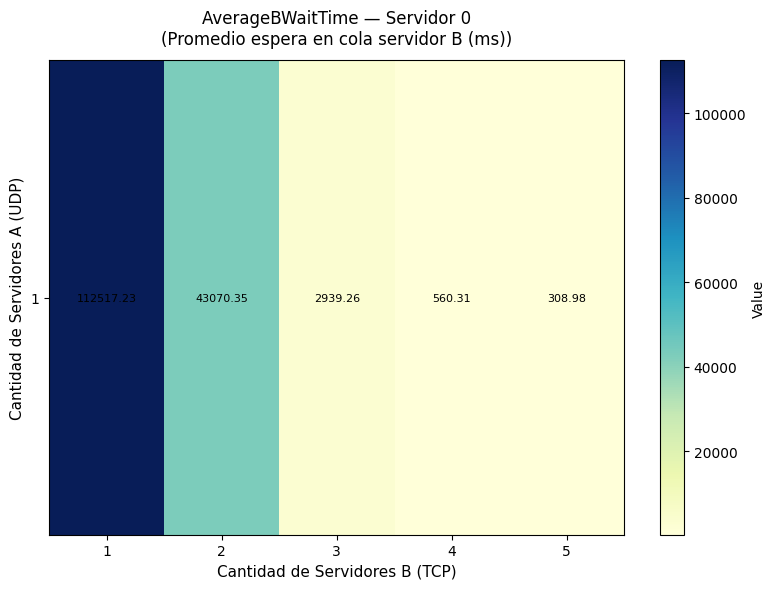


--- AverageBWaitTime [Servidor 1] ---
Mejor valor: 226.1986
-> N=1, M=5


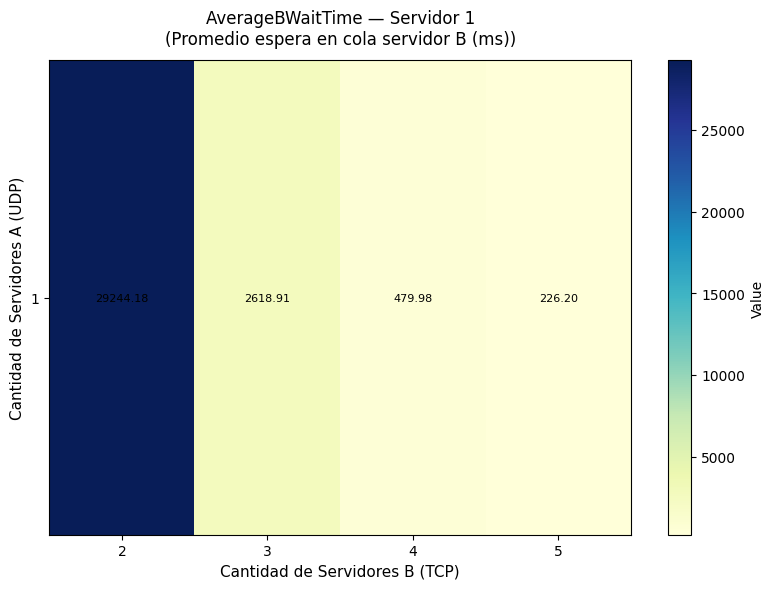


--- AverageBWaitTime [Servidor 2] ---
Mejor valor: 167.1037
-> N=1, M=5


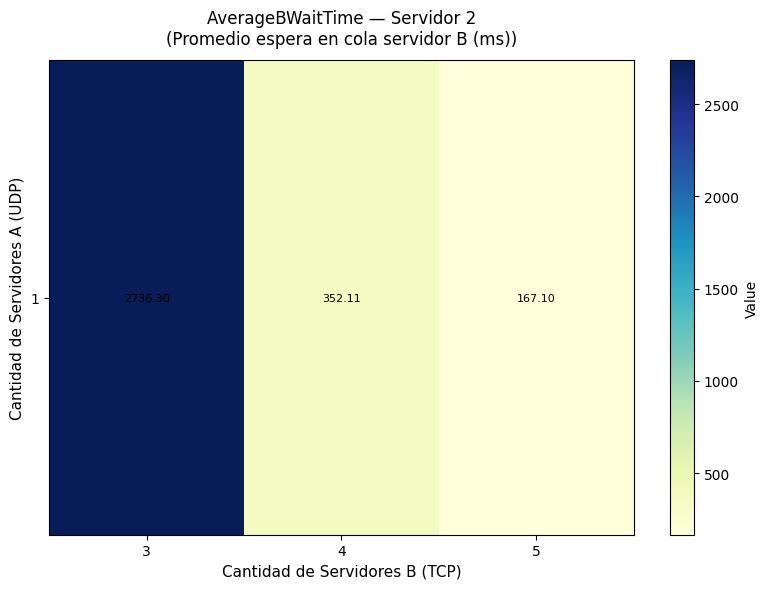


--- AverageBWaitTime [Servidor 3] ---
Mejor valor: 123.4542
-> N=1, M=5


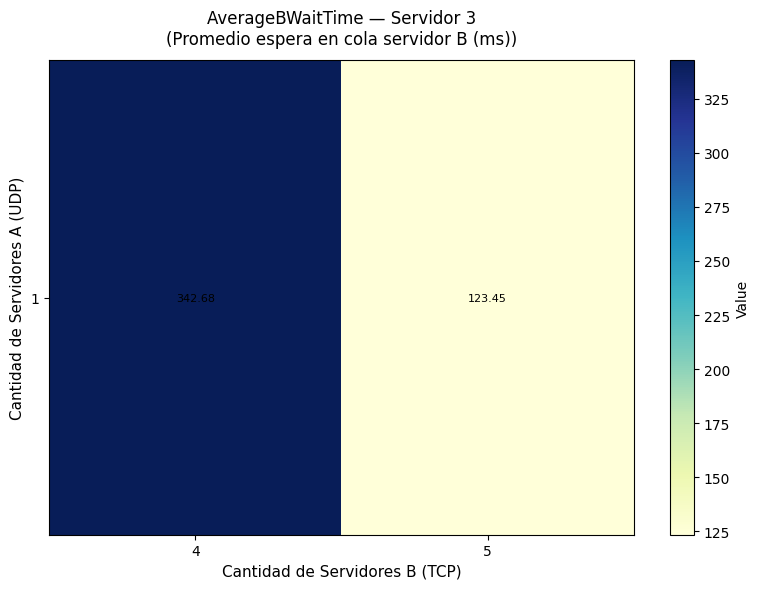


--- AverageBServiceTime [Servidor 0] ---
Mejor valor: 1161.7318
-> N=1, M=5


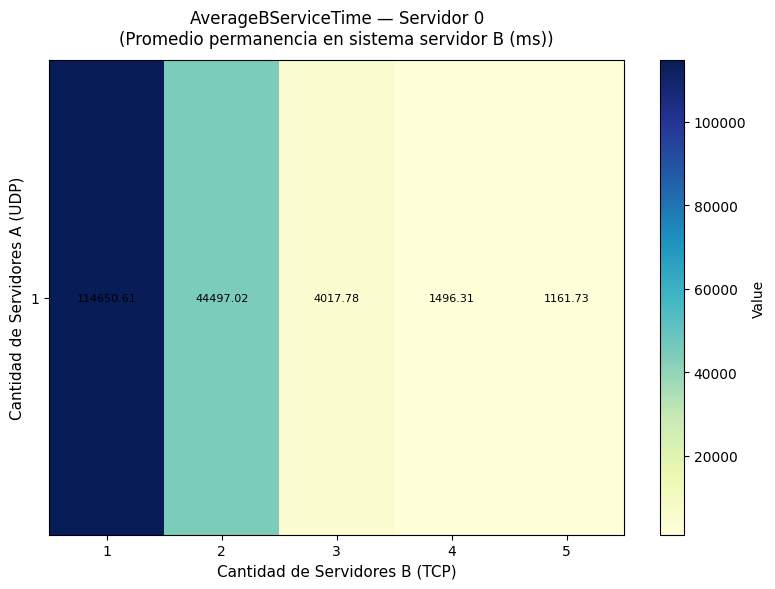


--- AverageBServiceTime [Servidor 1] ---
Mejor valor: 974.7013
-> N=1, M=5


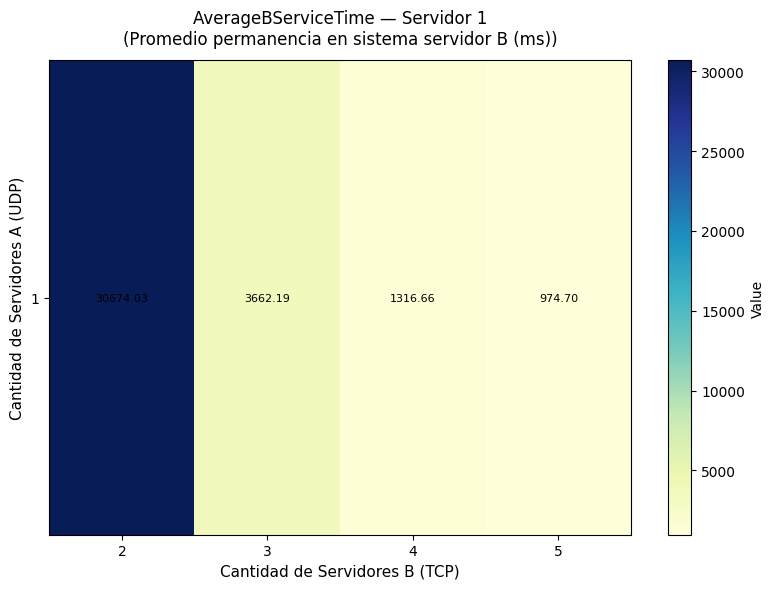


--- AverageBServiceTime [Servidor 2] ---
Mejor valor: 798.9363
-> N=1, M=5


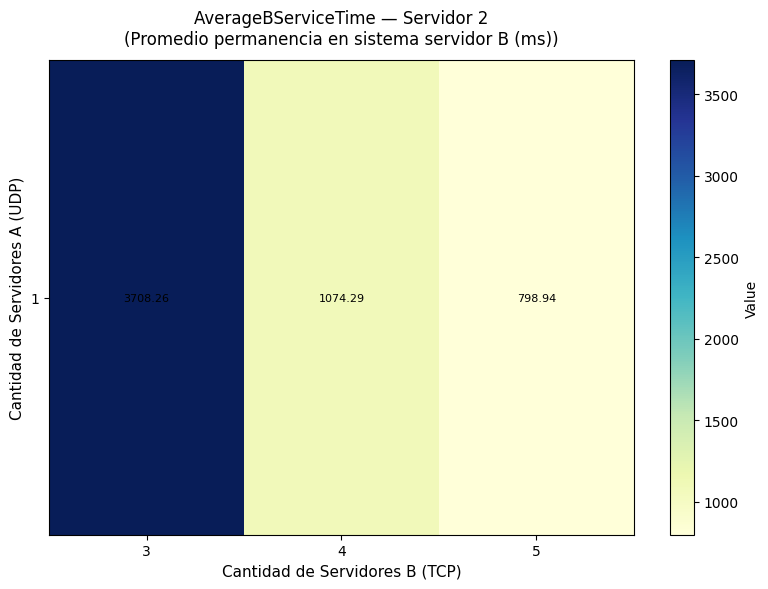


--- AverageBServiceTime [Servidor 3] ---
Mejor valor: 610.5301
-> N=1, M=5


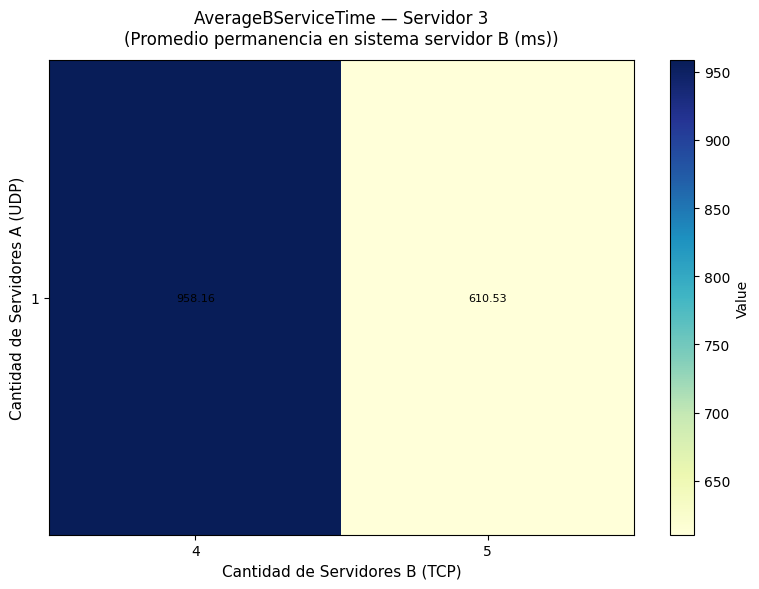

In [62]:
start_simulation(1,1)
start_simulation(2,3)
start_simulation(3,2)
start_simulation(4,1)
start_simulation(1,5)